In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install smogn

In [ ]:
## install developer version
!pip install git+https://github.com/nickkunz/smogn.git

  Cloning https://github.com/nickkunz/smogn.git to /tmp/pip-req-build-wunh7t5q
  Running command git clone --filter=blob:none --quiet https://github.com/nickkunz/smogn.git /tmp/pip-req-build-wunh7t5q
  Resolved https://github.com/nickkunz/smogn.git to commit e4e5e4aca43a07ebbd1a0ed881f4de1e24abb8ed
  Preparing metadata (setup.py) ... done
  Created wheel for smogn: filename=smogn-0.1.1-py3-none-any.whl size=31239 sha256=48ce17874e046d2c1dfb5f9b66873f48be63308d895f435b2e27a35d603b5dfa
  Stored in directory: /tmp/pip-ephem-wheel-cache-_3cev8cb/wheels/e5/ed/f1/7249493427ad035719e565198ec79a1189fc1f91c93f4c35b3
Successfully built smogn
  Attempting uninstall: smogn
    Found existing installation: smogn 0.1.2
    Uninstalling smogn-0.1.2:
      Successfully uninstalled smogn-0.1.2


In [ ]:
import smogn
import pandas as pd
import seaborn as sns

In [ ]:
import smogn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of CSV file paths
csv_files = [
    #'/content/drive/MyDrive/Colab Notebooks/Final_Dataset_PL.csv',
    # '/content/drive/MyDrive/Colab Notebooks/Final_Dataset_DE.csv',
    # '/content/drive/MyDrive/Colab Notebooks/Final_Dataset_SE.csv',
    '/content/drive/MyDrive/Colab Notebooks/Final_Dataset_FR.csv',
    #'/content/drive/MyDrive/Colab Notebooks/Final_Dataset_IT.csv'
]

# Process each file
for file_path in csv_files:
    # Load the dataset
    df = pd.read_csv(file_path)

    # Apply SMOGN
    df_smogn = smogn.smoter(data=df, y='average_speed_kmh')

    # Save the balanced dataset
    output_path = file_path.replace('.csv', '_smogn.csv')
    df_smogn.to_csv(output_path, index=False)

    # Print shape information
    print(f"Original shape for {file_path}: {df.shape}")
    print(f"Modified shape for {output_path}: {df_smogn.shape}")

    # Calculate and print statistical information
    original_stats = smogn.box_plot_stats(df['average_speed_kmh'])['stats']
    modified_stats = smogn.box_plot_stats(df_smogn['average_speed_kmh'])['stats']
    print(f"Original stats for {file_path}: {original_stats}")
    print(f"Modified stats for {output_path}: {modified_stats}")

    # Plot histograms
    df['average_speed_kmh'].plot(kind='hist', alpha=0.5, label='Original', bins=30)
    df_smogn['average_speed_kmh'].plot(kind='hist', alpha=0.5, label='SMOGN', bins=30)
    plt.xlabel('Average Speed (km/h)')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Average Speed in {file_path}')
    plt.legend()
    plt.show()

    # Plot KDE
    sns.kdeplot(df['average_speed_kmh'], label="Original")
    sns.kdeplot(df_smogn['average_speed_kmh'], label="SMOGN")
    plt.xlabel('Average Speed (km/h)')
    plt.ylabel('Density')
    plt.title(f'KDE of Average Speed in {file_path}')
    plt.legend()
    plt.show()


ValueError: redefine phi relevance function: all points are 1

In [ ]:
import pandas as pd
# Load the dataset
poland = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_Dataset_PL.csv')

In [ ]:
poland_smogn = smogn.smoter(
    data=poland,
    y='average_speed_kmh',
)

dist_matrix:   1%|1         | 36/2564 [01:23<1:37:50,  2.32s/it]


KeyboardInterrupt: 

In [ ]:
poland_smogn.head()

In [ ]:
print("Original shape:", poland.shape)
print("Modified shape:", poland_smogn.shape)

In [ ]:
original_stats = smogn.box_plot_stats(poland['average_speed_kmh'])['stats']
modified_stats = smogn.box_plot_stats(poland_smogn['average_speed_kmh'])['stats']
print("Original stats:", original_stats)
print("Modified stats:", modified_stats)


In [ ]:
import matplotlib.pyplot as plt

# Assuming your dataframes are named df1 and df2
poland['average_speed_kmh'].plot(kind='hist', alpha=0.5, label='poland', bins=30)
poland_smogn['average_speed_kmh'].plot(kind='hist', alpha=0.5, label='poland_smogn', bins=30)

plt.xlabel('Average Speed (km/h)')
plt.ylabel('Frequency')
plt.title('Distribution of Average Speed in Two DataFrames')
plt.legend()
plt.show()


In [ ]:
sns.kdeplot(poland['average_speed_kmh'], label="Original")
sns.kdeplot(poland_smogn['average_speed_kmh'], label="Modified")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
#warnings.filterwarnings('ignore')

# Load the dataset
df = poland_smogn

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# Extract temporal features from time column
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_columns = encoder.fit_transform(df[categorical_columns])

# Get the new column names
encoded_column_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoded_column_names, index=df.index)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original categorical columns
df.drop(columns=categorical_columns, inplace=True)

# # Create lag features for the target variable
df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
df['lag_speed_2'] = df['average_speed_kmh'].shift(2)
df['lag_speed_3'] = df['average_speed_kmh'].shift(3)

# # Create rolling average features for the target variable
df['rolling_mean_speed_3'] = df['average_speed_kmh'].rolling(window=3, min_periods=1).mean()
#df['rolling_mean_speed_5'] = df['average_speed_kmh'].rolling(window=5, min_periods=1).mean()

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by='time')

# Drop the first few rows where lag features would be NaN (after splitting the data)
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# # Display the first few rows of the DataFrame after all modifications
# print("Shape of the DataFrame:", df.shape)
# print("\nColumns in the DataFrame:\n", df.columns)

# # Show a sample of the features and target for training
# print("\nSample of the features (X) and target (y):")
# print(pd.concat([X.head(), y.head()], axis=1))

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# print("himal")
# print(pd.concat([X_test.head(10), y_test.head(10)], axis=1))
# print(pd.concat([X_train.head(10), y_train.head(10)], axis=1))

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'NeuralNetwork': MLPRegressor()
}

# Function to train and evaluate model
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)
    return mse, rmse, r2, mae, medae

# Dictionary to store results
results = {}

# Loop through models and evaluate
for model_name, model in models.items():
    mse, rmse, r2, mae, medae = train_and_evaluate_model(X_train, y_train, X_test, y_test, model)
    results[model_name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAE': mae, 'MedAE': medae}

# Displaying results
for model_name, metrics in results.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}')
    print('\n')


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
#warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_Dataset_PL.csv')

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# Extract temporal features from time column
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_columns = encoder.fit_transform(df[categorical_columns])

# Get the new column names
encoded_column_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoded_column_names, index=df.index)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original categorical columns
df.drop(columns=categorical_columns, inplace=True)

# # Create lag features for the target variable
#df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
#df['lag_speed_2'] = df['average_speed_kmh'].shift(2)
#df['lag_speed_3'] = df['average_speed_kmh'].shift(3)

# # Create rolling average features for the target variable
#df['rolling_mean_speed_3'] = df['average_speed_kmh'].rolling(window=3, min_periods=1).mean()
#df['rolling_mean_speed_5'] = df['average_speed_kmh'].rolling(window=5, min_periods=1).mean()

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by='time')

# Drop the first few rows where lag features would be NaN (after splitting the data)
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# # Display the first few rows of the DataFrame after all modifications
# print("Shape of the DataFrame:", df.shape)
# print("\nColumns in the DataFrame:\n", df.columns)

# # Show a sample of the features and target for training
# print("\nSample of the features (X) and target (y):")
# print(pd.concat([X.head(), y.head()], axis=1))

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("himal")
print(pd.concat([X_test.head(10), y_test.head(10)], axis=1))
print(pd.concat([X_train.head(10), y_train.head(10)], axis=1))

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'NeuralNetwork': MLPRegressor()
}

# Function to train and evaluate model
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)
    return mse, rmse, r2, mae, medae

# Dictionary to store results
results = {}

# Loop through models and evaluate
for model_name, model in models.items():
    mse, rmse, r2, mae, medae = train_and_evaluate_model(X_train, y_train, X_test, y_test, model)
    results[model_name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAE': mae, 'MedAE': medae}

# Displaying results
for model_name, metrics in results.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}')
    print('\n')


In [ ]:
# Calculate correlation matrix
correlation_matrix = df[['average_speed_kmh', 'lag_speed_1', 'lag_speed_2', 'lag_speed_3', 'rolling_mean_speed_3']].corr()

# Display the correlation matrix
print("Correlation Matrix:\n")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Display pairwise correlations
print("\nPairwise Correlations:")
for col in ['lag_speed_1', 'lag_speed_2', 'lag_speed_3', 'rolling_mean_speed_3']:
    print(f'Correlation between average_speed_kmh and {col}: {df["average_speed_kmh"].corr(df[col]):.4f}')

# Display correlations between lag features
print("\nCorrelations between Lag Features:")
for col1 in ['lag_speed_1', 'lag_speed_2', 'lag_speed_3']:
    for col2 in ['lag_speed_1', 'lag_speed_2', 'lag_speed_3']:
        if col1 != col2:
            print(f'Correlation between {col1} and {col2}: {df[col1].corr(df[col2]):.4f}')


In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, scoring='r2', n_jobs=-1,
                                                            train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.title(f'Learning Curve: {title}')
    plt.xlabel('Training examples')
    plt.ylabel('Score')
    plt.legend(loc='best')
    plt.show()

# Example for one model (e.g., RandomForest)
plot_learning_curve(models['RandomForest'], X_train, y_train, 'RandomForest')


In [ ]:
# Plotting Actual vs. Predicted Values for each model
for model_name, model in models.items():
    predictions = model.predict(X_test)

    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, predictions, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
    plt.title(f'{model_name} - Actual vs Predicted')
    plt.xlabel('Actual Speed (km/h)')
    plt.ylabel('Predicted Speed (km/h)')
    plt.show()


In [ ]:
# Residual plot for each model
for model_name, model in models.items():
    predictions = model.predict(X_test)
    residuals = y_test - predictions

    plt.figure(figsize=(10, 6))
    plt.scatter(predictions, residuals, alpha=0.3)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'{model_name} - Residual Plot')
    plt.xlabel('Predicted Speed (km/h)')
    plt.ylabel('Residuals')
    plt.show()


In [ ]:
# Displaying a few examples of actual vs predicted values
df_predictions = pd.DataFrame({'Actual': y_test, 'Predicted': models['RandomForest'].predict(X_test)})
print(df_predictions.head(50))  # Display the first 10 predictions


Feature Importance

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_Dataset_DE.csv')

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# Extract temporal features from time column
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_columns = encoder.fit_transform(df[categorical_columns])

# Get the new column names
encoded_column_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoded_column_names, index=df.index)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original categorical columns
df.drop(columns=categorical_columns, inplace=True)

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by=['collection_car', 'time'])

# Drop the first few rows where lag features would be NaN (after splitting the data)
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'NeuralNetwork': MLPRegressor(max_iter=1000),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'GradientBoosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'KNeighbors': KNeighborsRegressor(),
    'SVR': SVR()
}

# Function to train and evaluate model
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)

    # Feature importance extraction (if applicable)
    feature_importances = None
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        feature_importances = model.coef_

    return mse, rmse, r2, mae, medae, predictions, feature_importances

# Dictionary to store results
results = {}

# Loop through models and evaluate
for model_name, model in models.items():
    mse, rmse, r2, mae, medae, predictions, feature_importances = train_and_evaluate_model(X_train, y_train, X_test, y_test, model)
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae,
        'MedAE': medae,
        'Predictions': predictions,
        'FeatureImportances': feature_importances
    }

# Displaying results
for model_name, metrics in results.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}')
    if metrics['FeatureImportances'] is not None:
        print("Feature Importances:")
        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': metrics['FeatureImportances']
        }).sort_values(by='Importance', ascending=False)
        print(importance_df)
    print('\n')

print(pd.concat([X.head(), y.head()], axis=1))


Model: LinearRegression, R2: 0.6530, MAE: 11.8989, RMSE: 15.2960, MedAE: 9.6603
Feature Importances:
                                  Feature    Importance
32                      road_type_highway  4.005558e+01
39                 weather_condition_rain  2.683764e+00
40                    road_condition_snow  1.870524e+00
35               weather_condition_cloudy  1.491417e+00
38  weather_condition_partly-cloudy-night  1.418256e+00
37    weather_condition_partly-cloudy-day  1.335745e+00
26                            day_of_week  3.085127e-01
4                      num_lane_instances  2.846008e-01
9              num_traffic_signs_ego_lane  1.057723e-01
27                           day_of_month  5.158036e-02
18          num_dynamic_barriers_ego_road  2.398082e-14
14            num_traffic_guides_ego_road  2.353673e-14
16           num_traffic_beacons_ego_road  9.880985e-15
36                  weather_condition_fog  0.000000e+00
15           num_traffic_beacons_ego_lane -8.437695e-15
17 

Feature Importance Visualization

<Figure size 1000x800 with 0 Axes>

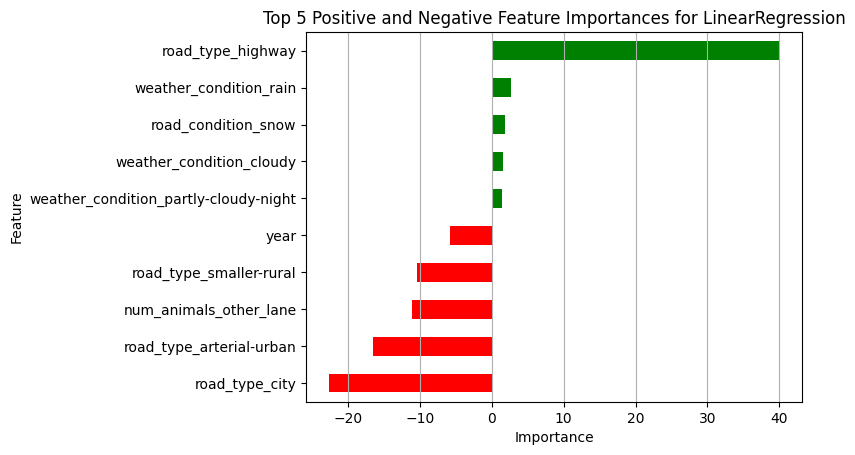

<Figure size 1000x800 with 0 Axes>

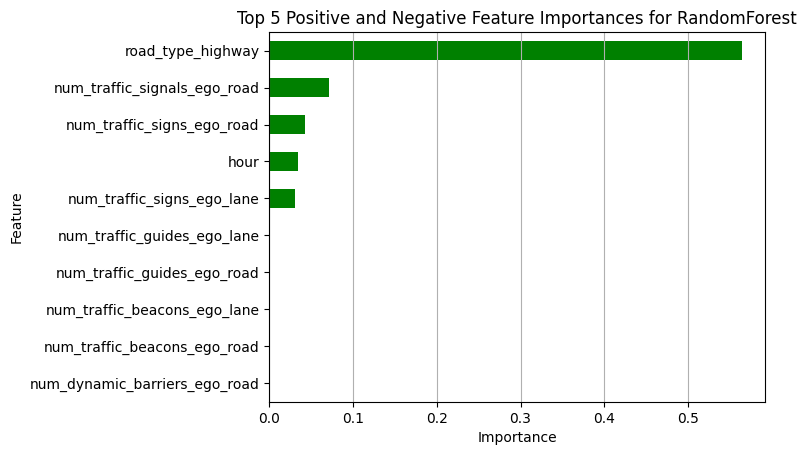

<Figure size 1000x800 with 0 Axes>

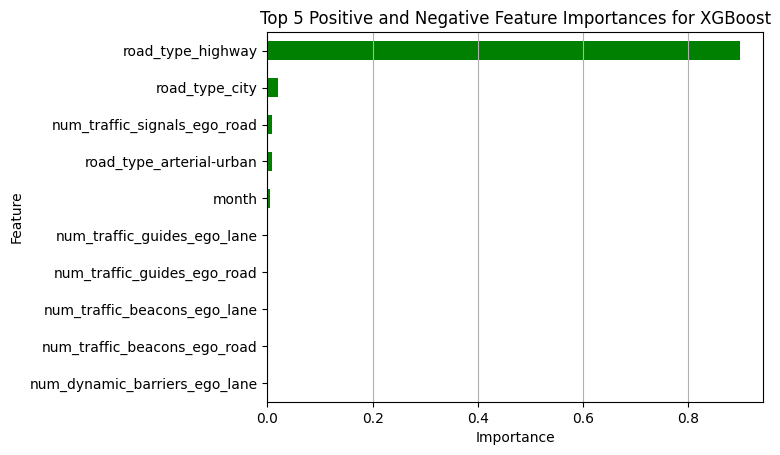

<Figure size 1000x800 with 0 Axes>

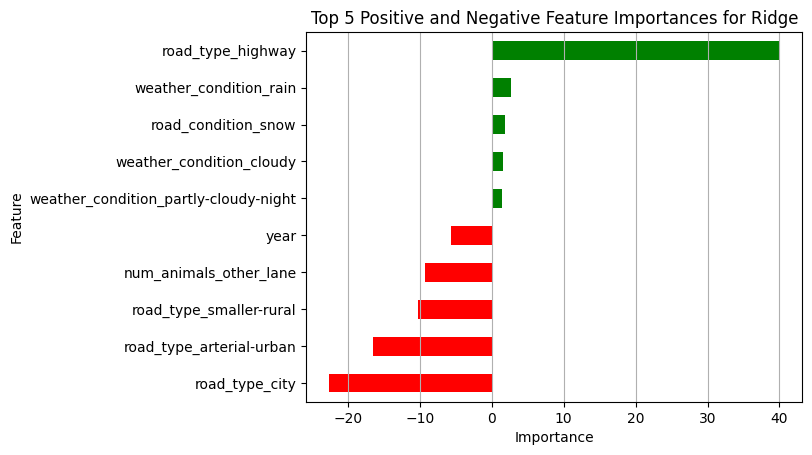

<Figure size 1000x800 with 0 Axes>

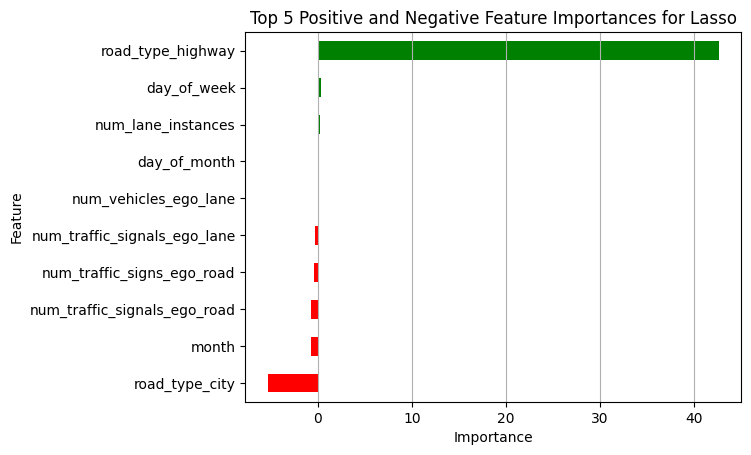

<Figure size 1000x800 with 0 Axes>

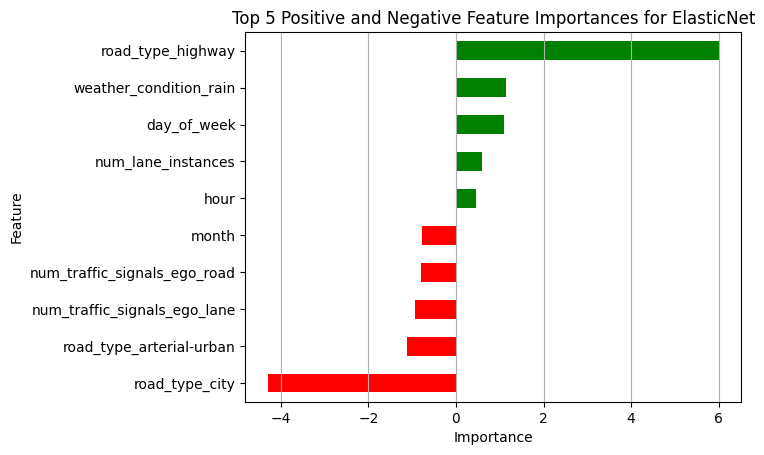

<Figure size 1000x800 with 0 Axes>

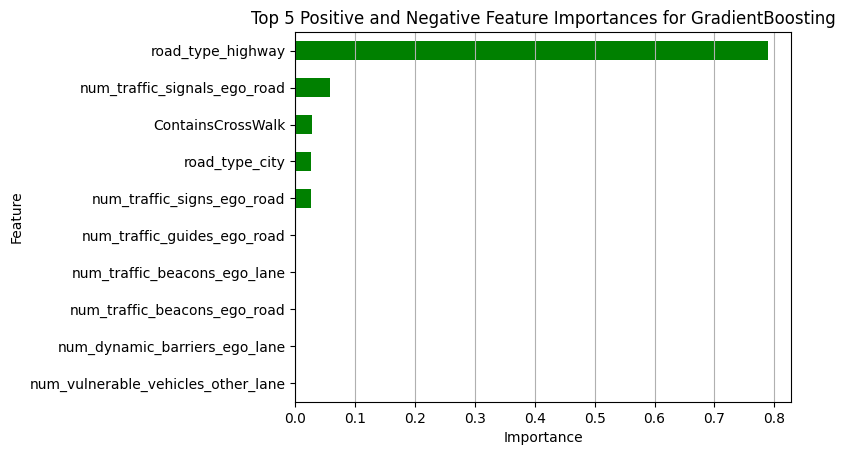

<Figure size 1000x800 with 0 Axes>

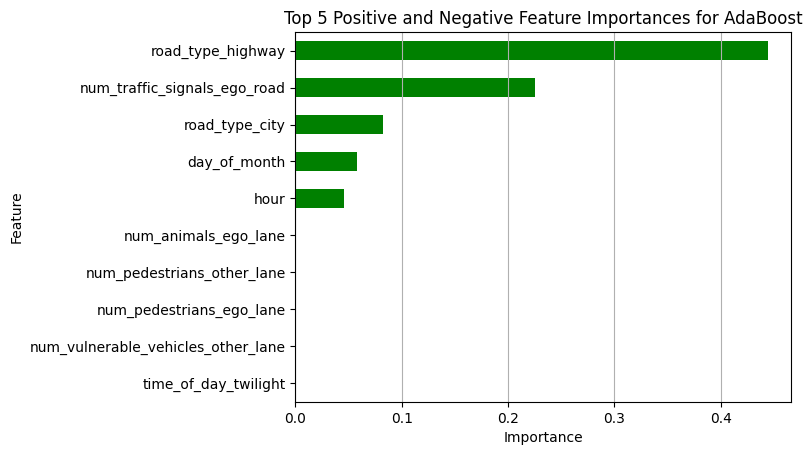

<Figure size 1000x800 with 0 Axes>

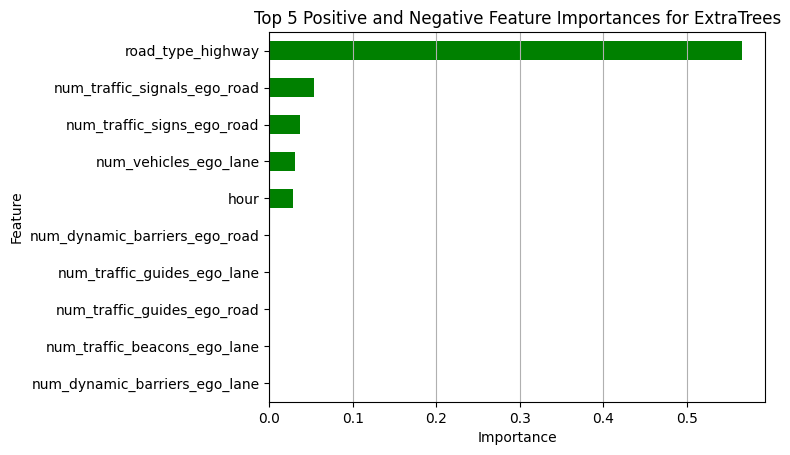

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance(importance_df, model_name):
    # Sort the importance values to get top 5 positive and negative features
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Select top 5 positive and top 5 negative features
    top_positive = sorted_importance_df.head(5)
    top_negative = sorted_importance_df.tail(5)

    # Combine them for visualization
    filtered_importance_df = pd.concat([top_positive, top_negative])

    # Plot the feature importances as a horizontal bar chart
    plt.figure(figsize=(10, 8))
    filtered_importance_df.plot(
        kind='barh',
        x='Feature',
        y='Importance',
        legend=False,
        color=(filtered_importance_df['Importance'] > 0).map({True: 'green', False: 'red'})
    )
    plt.xlabel('Importance')
    plt.title(f'Top 5 Positive and Negative Feature Importances for {model_name}')
    plt.grid(True, axis='x')
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest importance at the top
    plt.show()

# Example usage (after the model evaluation loop):
for model_name, metrics in results.items():
    if metrics['FeatureImportances'] is not None:
        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': metrics['FeatureImportances']
        })
        plot_feature_importance(importance_df, model_name)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_Dataset_DE.csv')

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# Extract temporal features from time column
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_columns = encoder.fit_transform(df[categorical_columns])

# Get the new column names
encoded_column_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoded_column_names, index=df.index)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original categorical columns
df.drop(columns=categorical_columns, inplace=True)

# Create lag features for the target variable
df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
#df['lag_speed_2'] = df['average_speed_kmh'].shift(2)
#df['lag_speed_3'] = df['average_speed_kmh'].shift(3)

# Create rolling average features for the target variable
#df['rolling_mean_speed_3'] = df['average_speed_kmh'].rolling(window=3, min_periods=1).mean()
#df['rolling_mean_speed_5'] = df['average_speed_kmh'].rolling(window=5, min_periods=1).mean()

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by=['collection_car', 'time'])

# Drop the first few rows where lag features would be NaN (after splitting the data)
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'NeuralNetwork': MLPRegressor(max_iter=1000),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'GradientBoosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'KNeighbors': KNeighborsRegressor(),
    'SVR': SVR()
}

# Function to train and evaluate model
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)

    # Feature importance extraction (if applicable)
    feature_importances = None
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        feature_importances = model.coef_

    return mse, rmse, r2, mae, medae, predictions, feature_importances

# Dictionary to store results
results = {}

# Loop through models and evaluate
for model_name, model in models.items():
    mse, rmse, r2, mae, medae, predictions, feature_importances = train_and_evaluate_model(X_train, y_train, X_test, y_test, model)
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae,
        'MedAE': medae,
        'Predictions': predictions,
        'FeatureImportances': feature_importances
    }

# Displaying results
for model_name, metrics in results.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}')
    if metrics['FeatureImportances'] is not None:
        print("Feature Importances:")
        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': metrics['FeatureImportances']
        }).sort_values(by='Importance', ascending=False)
        print(importance_df)
    print('\n')

print(pd.concat([X.head(), y.head()], axis=1))


Model: LinearRegression, R2: 0.7120, MAE: 10.5782, RMSE: 13.9348, MedAE: 7.9833
Feature Importances:
                                  Feature    Importance
32                      road_type_highway  2.616933e+01
40                    road_condition_snow  1.988337e+00
39                 weather_condition_rain  1.317347e+00
38  weather_condition_partly-cloudy-night  1.030459e+00
35               weather_condition_cloudy  8.950281e-01
37    weather_condition_partly-cloudy-day  8.903383e-01
44                            lag_speed_1  3.636437e-01
4                      num_lane_instances  2.789920e-01
9              num_traffic_signs_ego_lane  1.363768e-01
26                            day_of_week  1.250797e-01
20                    ContainsTrafficSign  6.493936e-02
27                           day_of_month  3.403427e-02
1                 num_vehicles_other_lane  1.158957e-02
16           num_traffic_beacons_ego_road  2.220446e-14
14            num_traffic_guides_ego_road  1.421085e-14
17 

<Figure size 1000x800 with 0 Axes>

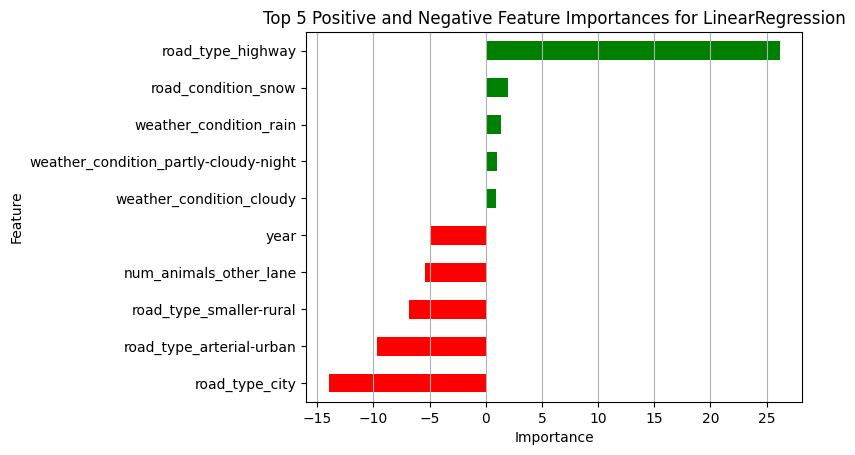

<Figure size 1000x800 with 0 Axes>

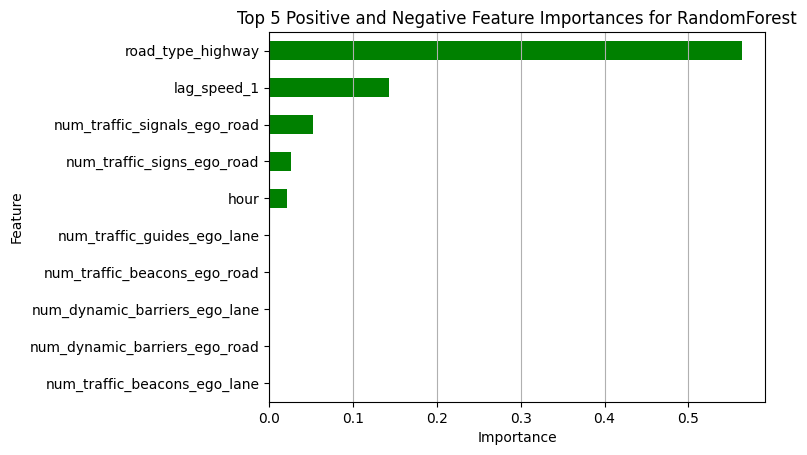

<Figure size 1000x800 with 0 Axes>

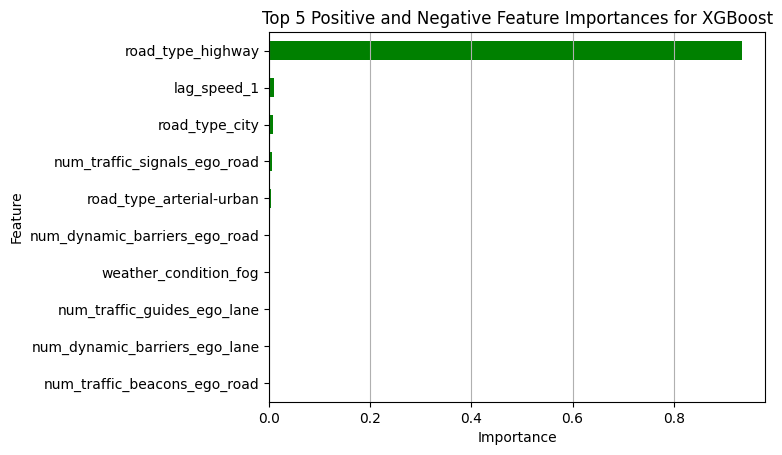

<Figure size 1000x800 with 0 Axes>

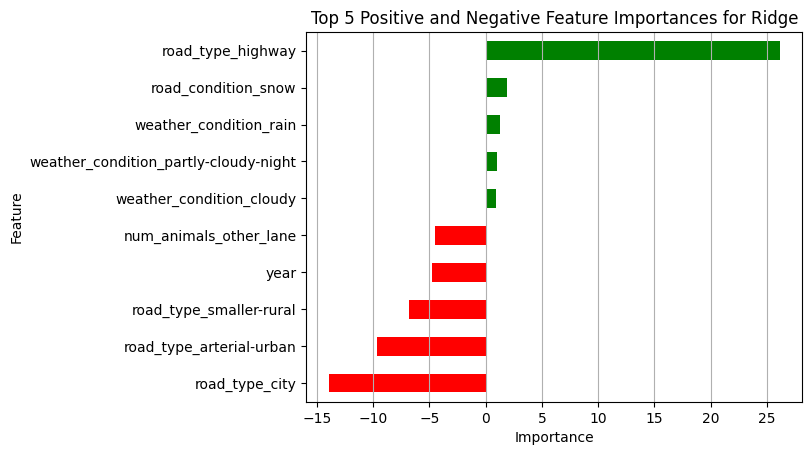

<Figure size 1000x800 with 0 Axes>

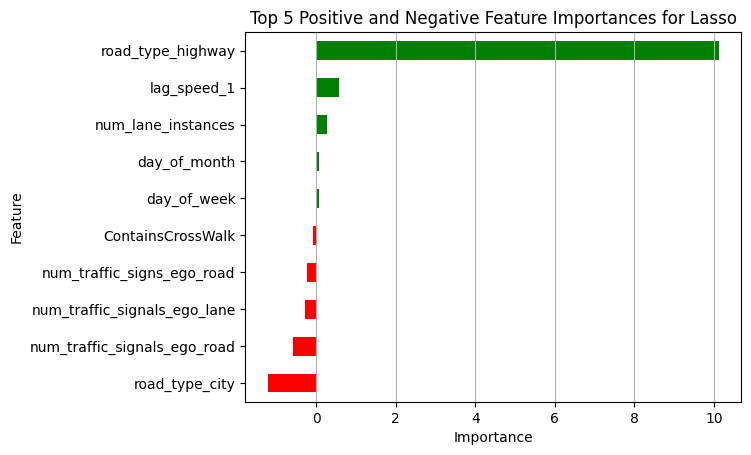

<Figure size 1000x800 with 0 Axes>

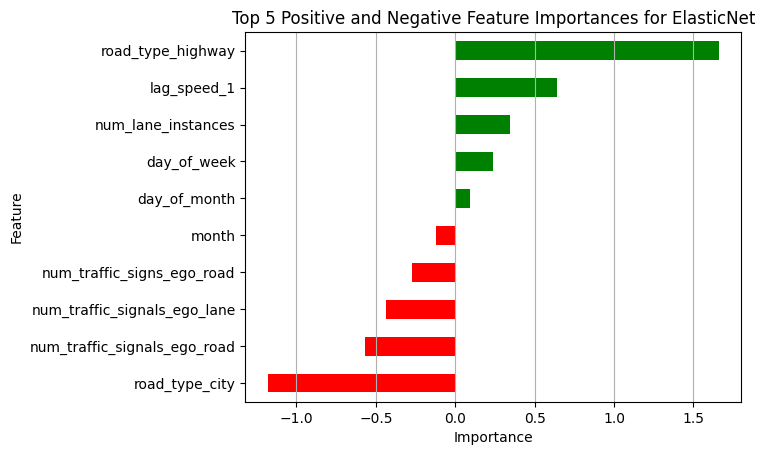

<Figure size 1000x800 with 0 Axes>

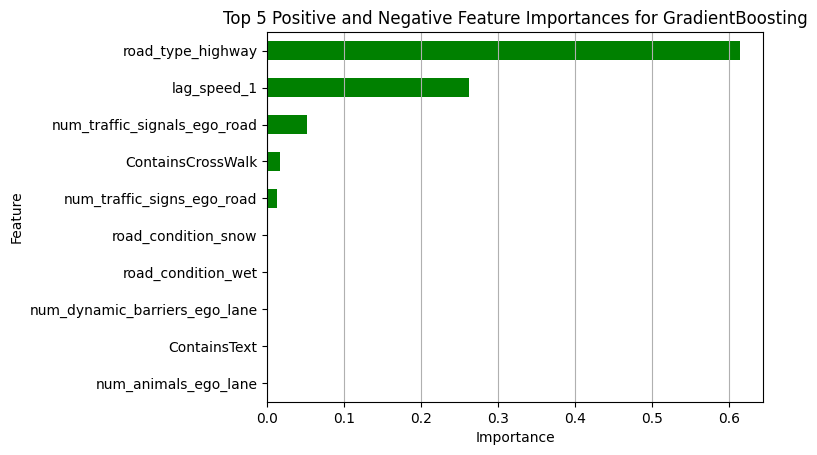

<Figure size 1000x800 with 0 Axes>

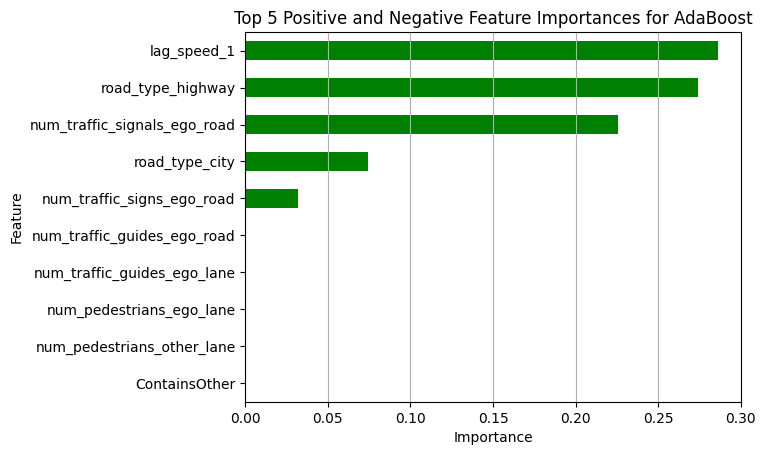

<Figure size 1000x800 with 0 Axes>

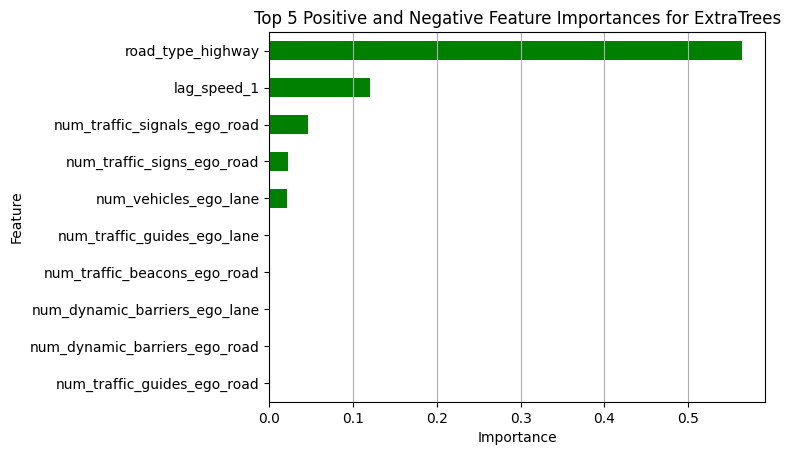

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance(importance_df, model_name):
    # Sort the importance values to get top 5 positive and negative features
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Select top 5 positive and top 5 negative features
    top_positive = sorted_importance_df.head(5)
    top_negative = sorted_importance_df.tail(5)

    # Combine them for visualization
    filtered_importance_df = pd.concat([top_positive, top_negative])

    # Plot the feature importances as a horizontal bar chart
    plt.figure(figsize=(10, 8))
    filtered_importance_df.plot(
        kind='barh',
        x='Feature',
        y='Importance',
        legend=False,
        color=(filtered_importance_df['Importance'] > 0).map({True: 'green', False: 'red'})
    )
    plt.xlabel('Importance')
    plt.title(f'Top 5 Positive and Negative Feature Importances for {model_name}')
    plt.grid(True, axis='x')
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest importance at the top
    plt.show()

# Example usage (after the model evaluation loop):
for model_name, metrics in results.items():
    if metrics['FeatureImportances'] is not None:
        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': metrics['FeatureImportances']
        })
        plot_feature_importance(importance_df, model_name)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_Dataset_DE.csv')

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# Extract temporal features from time column
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_columns = encoder.fit_transform(df[categorical_columns])

# Get the new column names
encoded_column_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoded_column_names, index=df.index)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original categorical columns
df.drop(columns=categorical_columns, inplace=True)

# Create lag features for the target variable
df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
df['lag_speed_2'] = df['average_speed_kmh'].shift(2)
#df['lag_speed_3'] = df['average_speed_kmh'].shift(3)

# Create rolling average features for the target variable
#df['rolling_mean_speed_3'] = df['average_speed_kmh'].rolling(window=3, min_periods=1).mean()
#df['rolling_mean_speed_5'] = df['average_speed_kmh'].rolling(window=5, min_periods=1).mean()

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by=['collection_car', 'time'])

# Drop the first few rows where lag features would be NaN (after splitting the data)
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'NeuralNetwork': MLPRegressor(max_iter=1000),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'GradientBoosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'KNeighbors': KNeighborsRegressor(),
    'SVR': SVR()
}

# Function to train and evaluate model
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)

    # Feature importance extraction (if applicable)
    feature_importances = None
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        feature_importances = model.coef_

    return mse, rmse, r2, mae, medae, predictions, feature_importances

# Dictionary to store results
results = {}

# Loop through models and evaluate
for model_name, model in models.items():
    mse, rmse, r2, mae, medae, predictions, feature_importances = train_and_evaluate_model(X_train, y_train, X_test, y_test, model)
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae,
        'MedAE': medae,
        'Predictions': predictions,
        'FeatureImportances': feature_importances
    }

# Displaying results
for model_name, metrics in results.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}')
    if metrics['FeatureImportances'] is not None:
        print("Feature Importances:")
        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': metrics['FeatureImportances']
        }).sort_values(by='Importance', ascending=False)
        print(importance_df)
    print('\n')

print(pd.concat([X.head(), y.head()], axis=1))


Model: LinearRegression, R2: 0.7146, MAE: 10.5180, RMSE: 13.8732, MedAE: 7.9512
Feature Importances:
                                  Feature    Importance
32                      road_type_highway  2.500492e+01
40                    road_condition_snow  1.966608e+00
39                 weather_condition_rain  1.158822e+00
38  weather_condition_partly-cloudy-night  9.980409e-01
37    weather_condition_partly-cloudy-day  8.415050e-01
35               weather_condition_cloudy  8.290370e-01
44                            lag_speed_1  3.291155e-01
4                      num_lane_instances  2.750142e-01
9              num_traffic_signs_ego_lane  1.398018e-01
26                            day_of_week  1.033032e-01
45                            lag_speed_2  6.796398e-02
20                    ContainsTrafficSign  5.566624e-02
3      num_vulnerable_vehicles_other_lane  4.098258e-02
27                           day_of_month  3.184782e-02
1                 num_vehicles_other_lane  2.039571e-02
17 

<Figure size 1000x800 with 0 Axes>

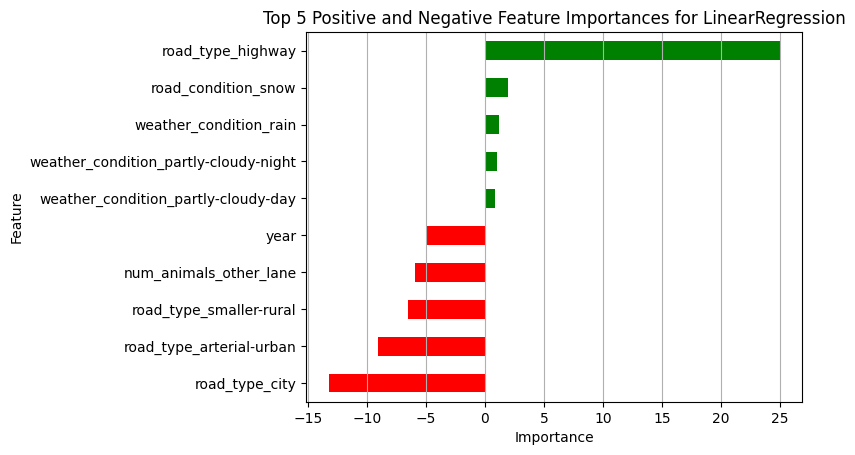

<Figure size 1000x800 with 0 Axes>

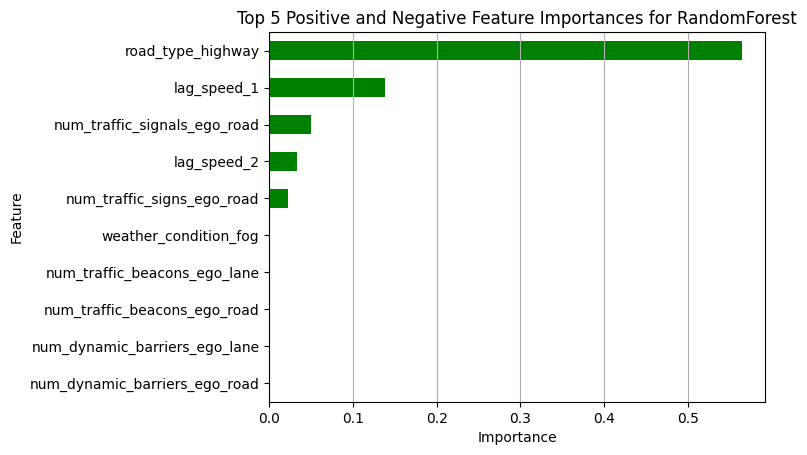

<Figure size 1000x800 with 0 Axes>

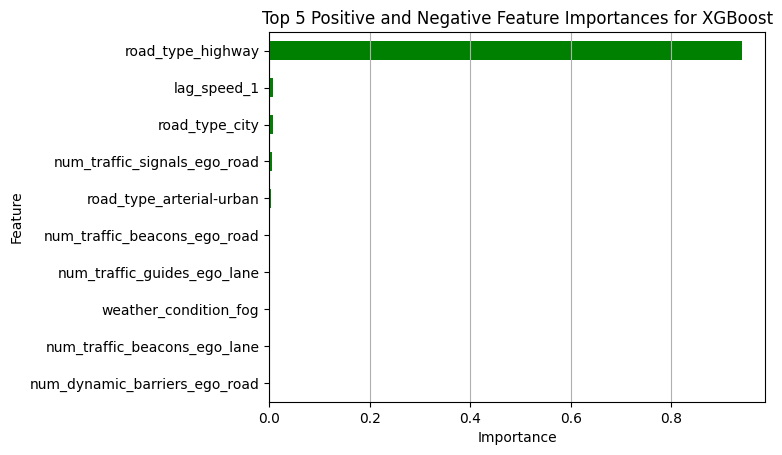

<Figure size 1000x800 with 0 Axes>

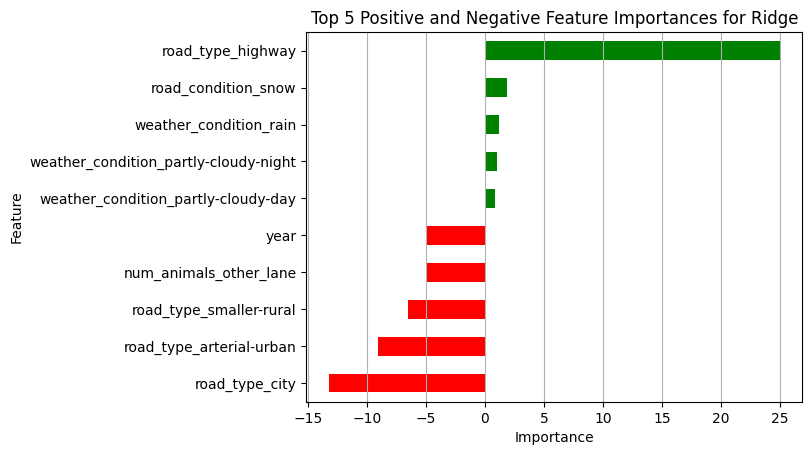

<Figure size 1000x800 with 0 Axes>

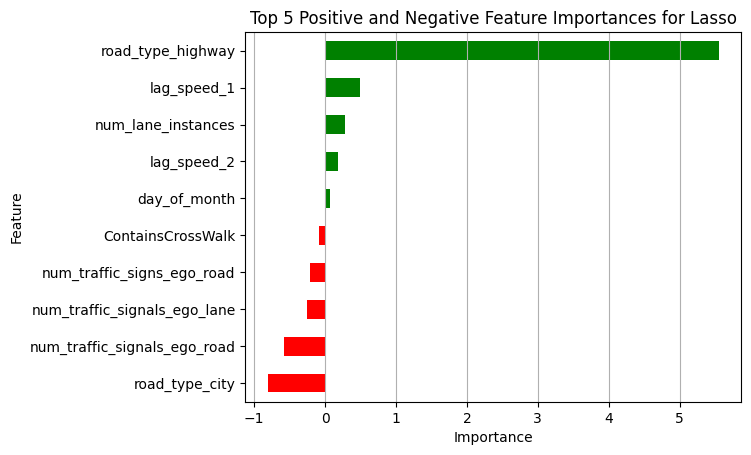

<Figure size 1000x800 with 0 Axes>

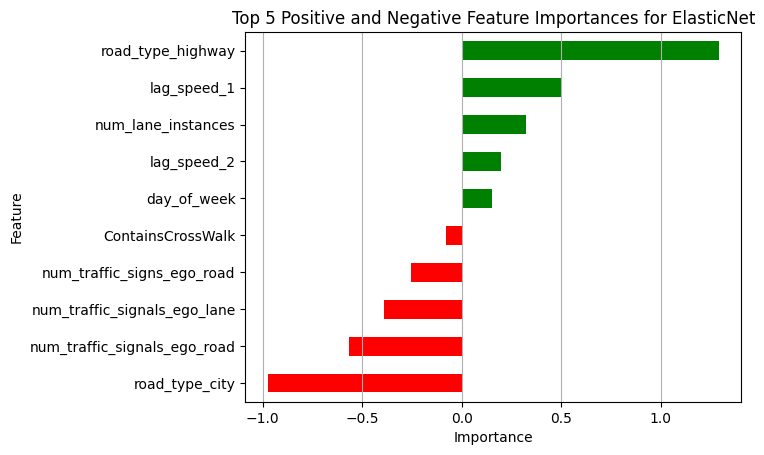

<Figure size 1000x800 with 0 Axes>

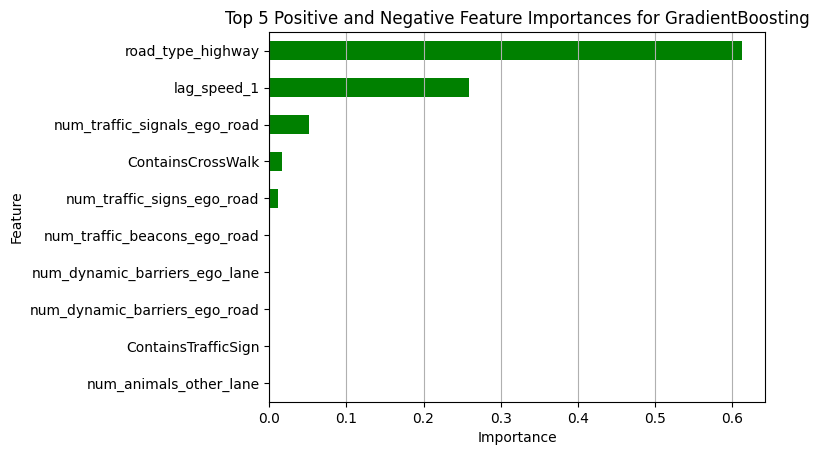

<Figure size 1000x800 with 0 Axes>

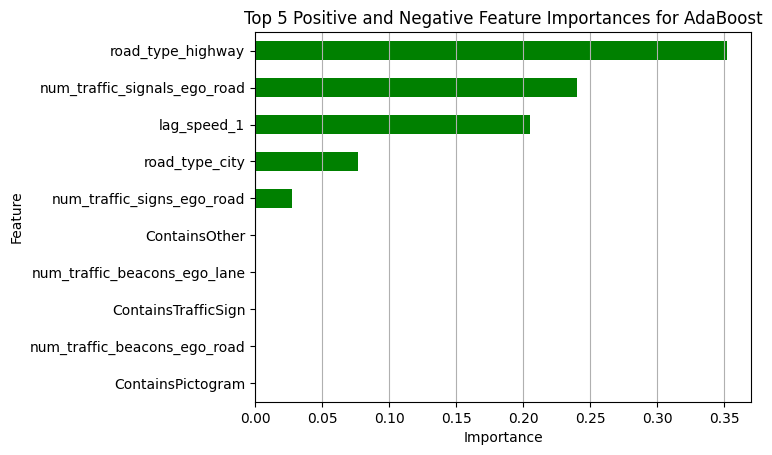

<Figure size 1000x800 with 0 Axes>

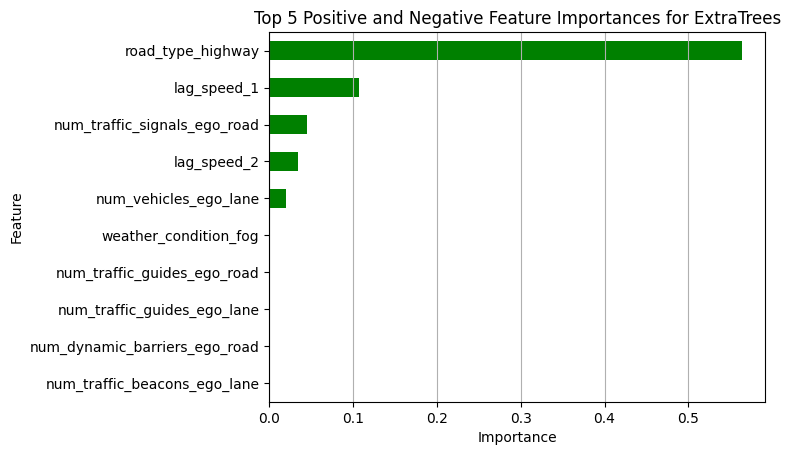

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance(importance_df, model_name):
    # Sort the importance values to get top 5 positive and negative features
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Select top 5 positive and top 5 negative features
    top_positive = sorted_importance_df.head(5)
    top_negative = sorted_importance_df.tail(5)

    # Combine them for visualization
    filtered_importance_df = pd.concat([top_positive, top_negative])

    # Plot the feature importances as a horizontal bar chart
    plt.figure(figsize=(10, 8))
    filtered_importance_df.plot(
        kind='barh',
        x='Feature',
        y='Importance',
        legend=False,
        color=(filtered_importance_df['Importance'] > 0).map({True: 'green', False: 'red'})
    )
    plt.xlabel('Importance')
    plt.title(f'Top 5 Positive and Negative Feature Importances for {model_name}')
    plt.grid(True, axis='x')
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest importance at the top
    plt.show()

# Example usage (after the model evaluation loop):
for model_name, metrics in results.items():
    if metrics['FeatureImportances'] is not None:
        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': metrics['FeatureImportances']
        })
        plot_feature_importance(importance_df, model_name)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_Dataset_DE.csv')

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# Extract temporal features from time column
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_columns = encoder.fit_transform(df[categorical_columns])

# Get the new column names
encoded_column_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoded_column_names, index=df.index)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original categorical columns
df.drop(columns=categorical_columns, inplace=True)

# Create lag features for the target variable
df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
df['lag_speed_2'] = df['average_speed_kmh'].shift(2)
df['lag_speed_3'] = df['average_speed_kmh'].shift(3)

# Create rolling average features for the target variable
#df['rolling_mean_speed_3'] = df['average_speed_kmh'].rolling(window=3, min_periods=1).mean()
#df['rolling_mean_speed_5'] = df['average_speed_kmh'].rolling(window=5, min_periods=1).mean()

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by=['collection_car', 'time'])

# Drop the first few rows where lag features would be NaN (after splitting the data)
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'NeuralNetwork': MLPRegressor(max_iter=1000),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'GradientBoosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'KNeighbors': KNeighborsRegressor(),
    'SVR': SVR()
}

# Function to train and evaluate model
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)

    # Feature importance extraction (if applicable)
    feature_importances = None
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        feature_importances = model.coef_

    return mse, rmse, r2, mae, medae, predictions, feature_importances

# Dictionary to store results
results = {}

# Loop through models and evaluate
for model_name, model in models.items():
    mse, rmse, r2, mae, medae, predictions, feature_importances = train_and_evaluate_model(X_train, y_train, X_test, y_test, model)
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae,
        'MedAE': medae,
        'Predictions': predictions,
        'FeatureImportances': feature_importances
    }

# Displaying results
for model_name, metrics in results.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}')
    if metrics['FeatureImportances'] is not None:
        print("Feature Importances:")
        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': metrics['FeatureImportances']
        }).sort_values(by='Importance', ascending=False)
        print(importance_df)
    print('\n')

print(pd.concat([X.head(), y.head()], axis=1))


Model: LinearRegression, R2: 0.7161, MAE: 10.4770, RMSE: 13.8370, MedAE: 7.9792
Feature Importances:
                                  Feature    Importance
32                      road_type_highway  2.437627e+01
40                    road_condition_snow  2.102765e+00
39                 weather_condition_rain  1.069411e+00
38  weather_condition_partly-cloudy-night  9.984819e-01
37    weather_condition_partly-cloudy-day  8.037625e-01
35               weather_condition_cloudy  7.856005e-01
44                            lag_speed_1  3.247624e-01
4                      num_lane_instances  2.731951e-01
9              num_traffic_signs_ego_lane  1.418909e-01
26                            day_of_week  9.233974e-02
3      num_vulnerable_vehicles_other_lane  8.876299e-02
20                    ContainsTrafficSign  5.199802e-02
45                            lag_speed_2  4.661693e-02
46                            lag_speed_3  4.391235e-02
27                           day_of_month  3.028769e-02
1  

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_Dataset_FR.csv')

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# Extract temporal features from time column
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_columns = encoder.fit_transform(df[categorical_columns])

# Get the new column names
encoded_column_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoded_column_names, index=df.index)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original categorical columns
df.drop(columns=categorical_columns, inplace=True)

# Create lag features for the target variable
df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
df['lag_speed_2'] = df['average_speed_kmh'].shift(2)
df['lag_speed_3'] = df['average_speed_kmh'].shift(3)

# Create rolling average features for the target variable
# df['rolling_mean_speed_3'] = df['average_speed_kmh'].rolling(window=3, min_periods=1).mean()
# df['rolling_mean_speed_5'] = df['average_speed_kmh'].rolling(window=5, min_periods=1).mean()

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by=['collection_car', 'time'])

# Drop the first few rows where lag features would be NaN (after splitting the data)
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'NeuralNetwork': MLPRegressor(max_iter=1000),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'GradientBoosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'KNeighbors': KNeighborsRegressor(),
    'SVR': SVR()
}

# Function to train and evaluate model
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)

    # Feature importance extraction (if applicable)
    feature_importances = None
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        feature_importances = model.coef_

    return mse, rmse, r2, mae, medae, predictions, feature_importances

# Dictionary to store results
results = {}

# Loop through models and evaluate
for model_name, model in models.items():
    mse, rmse, r2, mae, medae, predictions, feature_importances = train_and_evaluate_model(X_train, y_train, X_test, y_test, model)
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae,
        'MedAE': medae,
        'Predictions': predictions,
        'FeatureImportances': feature_importances
    }

# Displaying results
for model_name, metrics in results.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}')
    if metrics['FeatureImportances'] is not None:
        print("Feature Importances:")
        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': metrics['FeatureImportances']
        }).sort_values(by='Importance', ascending=False)
        print(importance_df)
    print('\n')

print(pd.concat([X.head(), y.head()], axis=1))


Model: LinearRegression, R2: 0.8673, MAE: 11.0063, RMSE: 14.9510, MedAE: 9.6986
Feature Importances:
                                  Feature    Importance
32                      road_type_highway  1.178750e+01
40                    road_condition_snow  6.901779e+00
6              num_pedestrians_other_lane  4.676017e+00
38                 weather_condition_rain  4.328111e+00
43                   time_of_day_twilight  3.111002e+00
42                      time_of_day_night  2.906492e+00
35               weather_condition_cloudy  1.888999e+00
4                      num_lane_instances  1.022560e+00
36    weather_condition_partly-cloudy-day  8.795119e-01
3      num_vulnerable_vehicles_other_lane  6.083617e-01
44                            lag_speed_1  5.008293e-01
24                           ContainsText  4.636989e-01
9              num_traffic_signs_ego_lane  1.171238e-01
1                 num_vehicles_other_lane  7.480574e-02
27                           day_of_month  5.142987e-02
46 

<Figure size 1000x800 with 0 Axes>

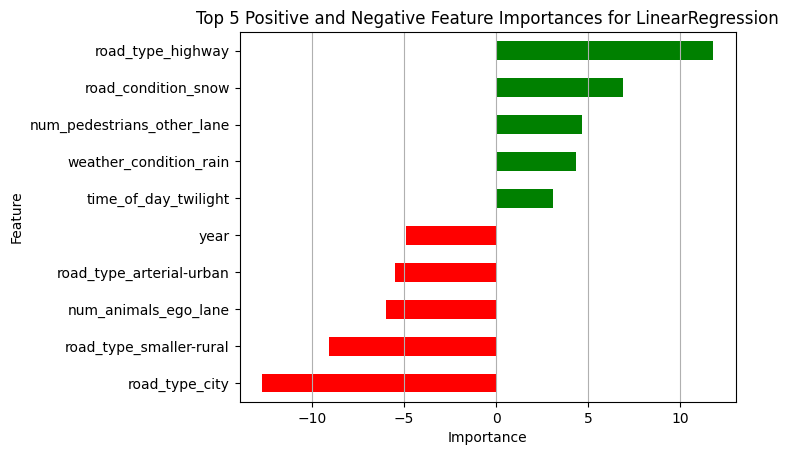

<Figure size 1000x800 with 0 Axes>

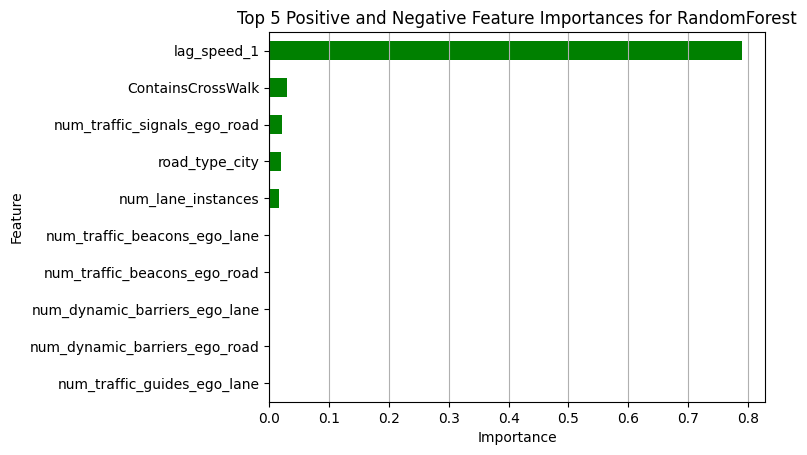

<Figure size 1000x800 with 0 Axes>

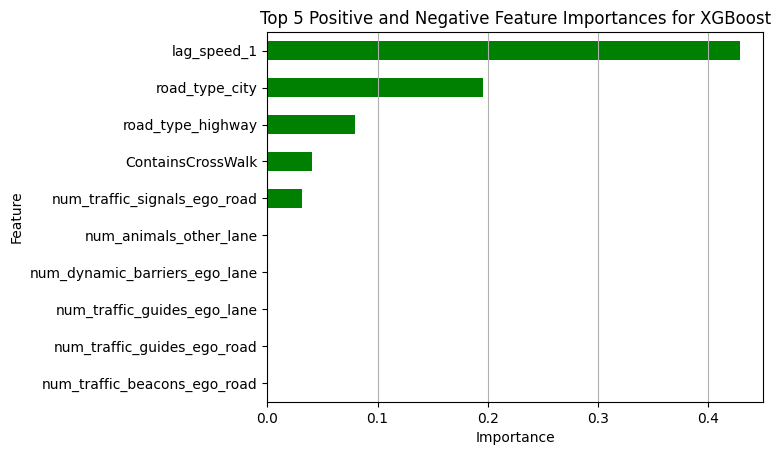

<Figure size 1000x800 with 0 Axes>

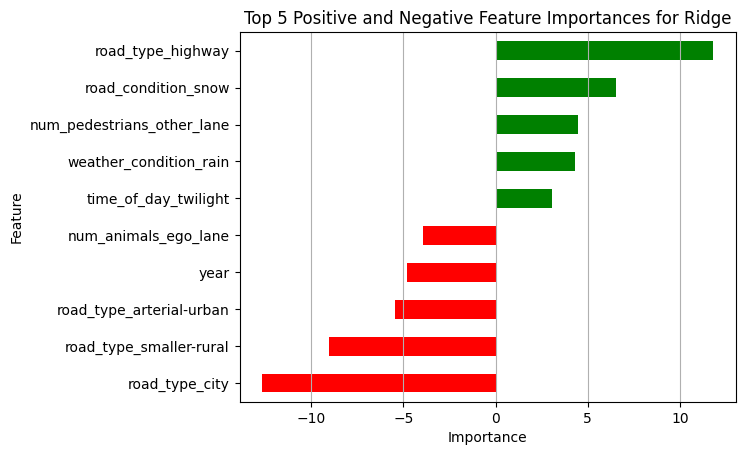

<Figure size 1000x800 with 0 Axes>

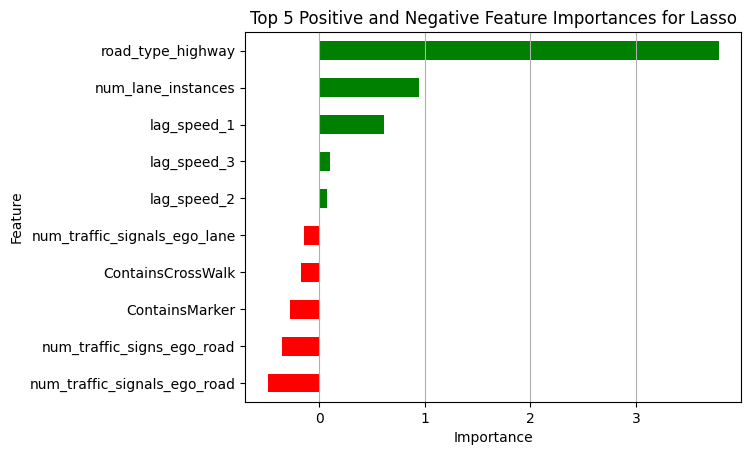

<Figure size 1000x800 with 0 Axes>

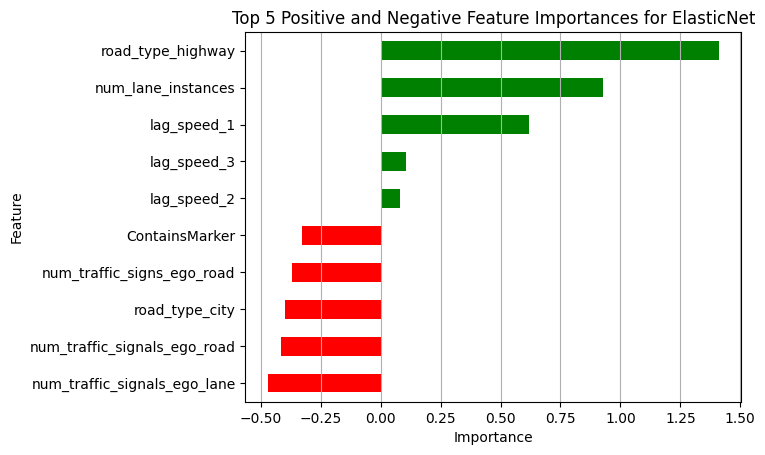

<Figure size 1000x800 with 0 Axes>

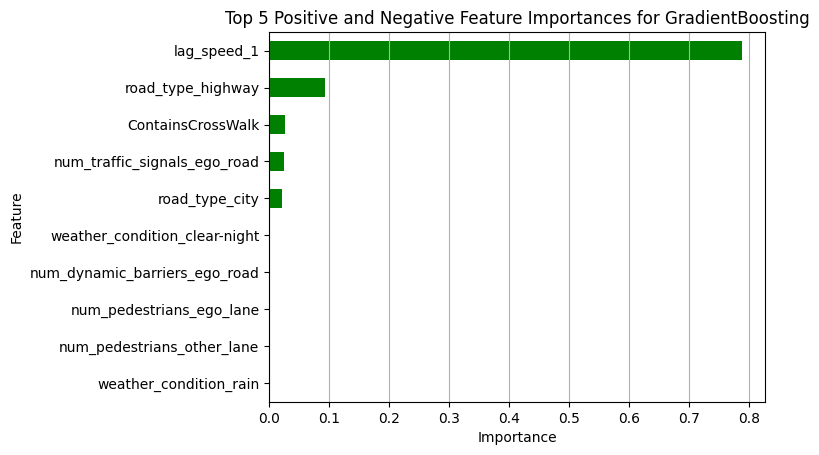

<Figure size 1000x800 with 0 Axes>

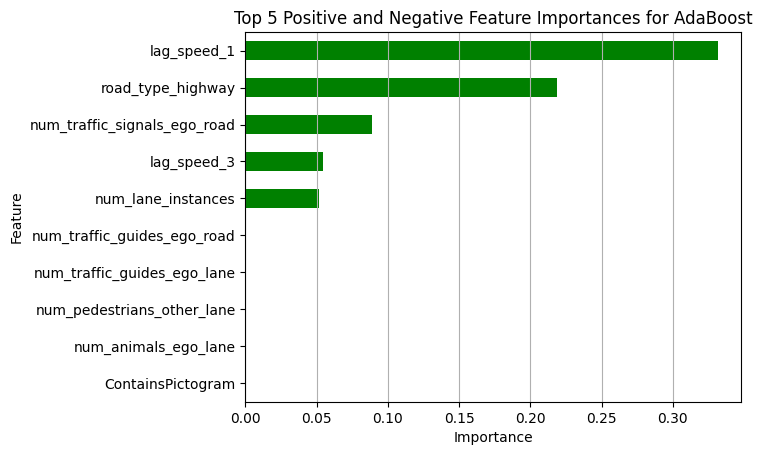

<Figure size 1000x800 with 0 Axes>

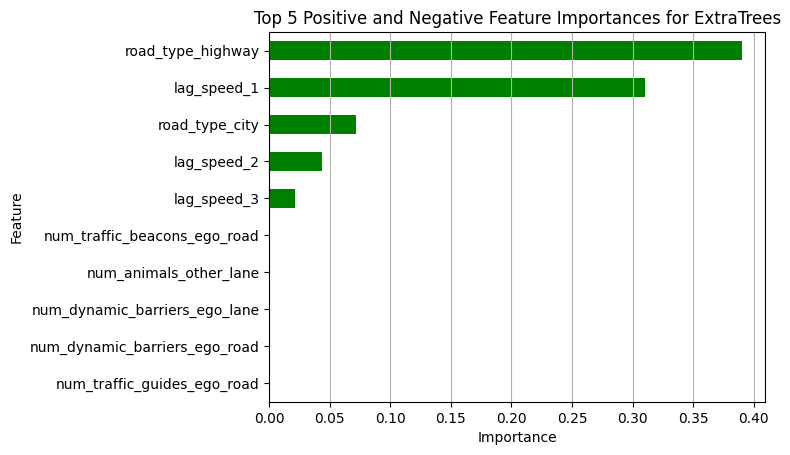

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance(importance_df, model_name):
    # Sort the importance values to get top 5 positive and negative features
    sorted_importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Select top 5 positive and top 5 negative features
    top_positive = sorted_importance_df.head(5)
    top_negative = sorted_importance_df.tail(5)

    # Combine them for visualization
    filtered_importance_df = pd.concat([top_positive, top_negative])

    # Plot the feature importances as a horizontal bar chart
    plt.figure(figsize=(10, 8))
    filtered_importance_df.plot(
        kind='barh',
        x='Feature',
        y='Importance',
        legend=False,
        color=(filtered_importance_df['Importance'] > 0).map({True: 'green', False: 'red'})
    )
    plt.xlabel('Importance')
    plt.title(f'Top 5 Positive and Negative Feature Importances for {model_name}')
    plt.grid(True, axis='x')
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest importance at the top
    plt.show()

# Example usage (after the model evaluation loop):
for model_name, metrics in results.items():
    if metrics['FeatureImportances'] is not None:
        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': metrics['FeatureImportances']
        })
        plot_feature_importance(importance_df, model_name)


Enddddddddddddddddddddddddd
Enddddddddddddddddddddddddd
Enddddddddddddddddddddddddd
Enddddddddddddddddddddddddd
Enddddddddddddddddddddddddd
Efficiency

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_Dataset_DE_smogn.csv')

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# Extract temporal features from time column
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_columns = encoder.fit_transform(df[categorical_columns])

# Get the new column names
encoded_column_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoded_column_names, index=df.index)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original categorical columns
df.drop(columns=categorical_columns, inplace=True)

# Create lag features for the target variable
df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
df['lag_speed_2'] = df['average_speed_kmh'].shift(2)
df['lag_speed_3'] = df['average_speed_kmh'].shift(3)

# Create rolling average features for the target variable
# df['rolling_mean_speed_3'] = df['average_speed_kmh'].rolling(window=3, min_periods=1).mean()
# df['rolling_mean_speed_5'] = df['average_speed_kmh'].rolling(window=5, min_periods=1).mean()

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by=['collection_car', 'time'])

# Drop the first few rows where lag features would be NaN (after splitting the data)
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'NeuralNetwork': MLPRegressor(max_iter=1000),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'GradientBoosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'KNeighbors': KNeighborsRegressor(),
    'SVR': SVR()
}

# Function to train and evaluate model
import time

# Function to train and evaluate model
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model):
    # Record the start time for training
    train_start_time = time.time()

    # Train the model
    model.fit(X_train, y_train)

    # Record the end time for training
    train_end_time = time.time()

    # Calculate the training time
    training_time = train_end_time - train_start_time

    # Record the start time for predictions
    pred_start_time = time.time()

    # Make predictions
    predictions = model.predict(X_test)

    # Record the end time for predictions
    pred_end_time = time.time()

    # Calculate the prediction time
    prediction_time = pred_end_time - pred_start_time

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)

    # Feature importance extraction (if applicable)
    feature_importances = None
    if hasattr(model, 'feature_importances_'):
        feature_importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        feature_importances = model.coef_

    return mse, rmse, r2, mae, medae, training_time, prediction_time, predictions, feature_importances

# Dictionary to store results
results = {}

# Loop through models and evaluate
for model_name, model in models.items():
    mse, rmse, r2, mae, medae, training_time, prediction_time, predictions, feature_importances = train_and_evaluate_model(X_train, y_train, X_test, y_test, model)
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae,
        'MedAE': medae,
        'TrainingTime': training_time,
        'PredictionTime': prediction_time,
        'Predictions': predictions,
        'FeatureImportances': feature_importances
    }

# Displaying results
for model_name, metrics in results.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}')
    print(f'Training Time: {metrics["TrainingTime"]:.4f} seconds, Prediction Time: {metrics["PredictionTime"]:.4f} seconds')
    if metrics['FeatureImportances'] is not None:
        #print("Feature Importances:")
        importance_df = pd.DataFrame({
            'Feature': X.columns,
            'Importance': metrics['FeatureImportances']
        }).sort_values(by='Importance', ascending=False)
        #print(importance_df)
    print('\n')

#print(pd.concat([X.head(), y.head()], axis=1))


Model: LinearRegression, R2: 0.7583, MAE: 11.3370, RMSE: 15.1538, MedAE: 8.5379
Training Time: 0.3605 seconds, Prediction Time: 0.0087 seconds


Model: RandomForest, R2: 0.7935, MAE: 10.2043, RMSE: 14.0081, MedAE: 7.4400
Training Time: 19.2536 seconds, Prediction Time: 0.1038 seconds


Model: XGBoost, R2: 0.7967, MAE: 10.2598, RMSE: 13.8978, MedAE: 7.5311
Training Time: 0.3220 seconds, Prediction Time: 0.0223 seconds


Model: NeuralNetwork, R2: 0.7722, MAE: 11.0195, RMSE: 14.7112, MedAE: 8.4644
Training Time: 7.6324 seconds, Prediction Time: 0.0055 seconds


Model: Ridge, R2: 0.7583, MAE: 11.3360, RMSE: 15.1529, MedAE: 8.5364
Training Time: 0.0094 seconds, Prediction Time: 0.0022 seconds


Model: Lasso, R2: 0.7210, MAE: 11.7027, RMSE: 16.2796, MedAE: 8.2884
Training Time: 0.0256 seconds, Prediction Time: 0.0038 seconds


Model: ElasticNet, R2: 0.7248, MAE: 11.6478, RMSE: 16.1700, MedAE: 8.2699
Training Time: 0.0390 seconds, Prediction Time: 0.0033 seconds


Model: GradientBoosting, R2:

Model: LinearRegression, R2: 0.7794, MAE: 11.4342, RMSE: 15.4499, MedAE: 8.4949


Model: RandomForest, R2: 0.8112, MAE: 10.4197, RMSE: 14.2922, MedAE: 7.5400


Model: XGBoost, R2: 0.8151, MAE: 10.5203, RMSE: 14.1424, MedAE: 7.8607


Model: NeuralNetwork, R2: 0.7960, MAE: 10.9435, RMSE: 14.8580, MedAE: 8.1046


Model: Ridge, R2: 0.7794, MAE: 11.4334, RMSE: 15.4492, MedAE: 8.4998


Model: Lasso, R2: 0.7435, MAE: 11.8746, RMSE: 16.6591, MedAE: 8.2717


Model: ElasticNet, R2: 0.7469, MAE: 11.8149, RMSE: 16.5475, MedAE: 8.3001


Model: GradientBoosting, R2: 0.8135, MAE: 10.5774, RMSE: 14.2072, MedAE: 7.9316


Model: AdaBoost, R2: 0.7327, MAE: 13.5527, RMSE: 17.0066, MedAE: 11.4292


Model: ExtraTrees, R2: 0.8195, MAE: 10.3205, RMSE: 13.9761, MedAE: 7.4300


Model: KNeighbors, R2: 0.7275, MAE: 12.1710, RMSE: 17.1713, MedAE: 8.4000


Model: SVR, R2: 0.5674, MAE: 16.8579, RMSE: 21.6356, MedAE: 13.6901




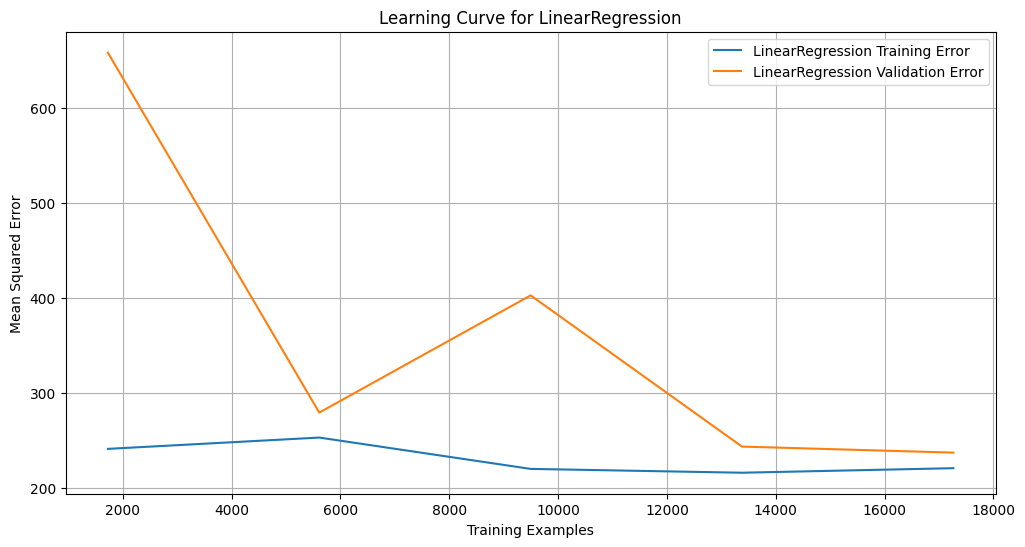

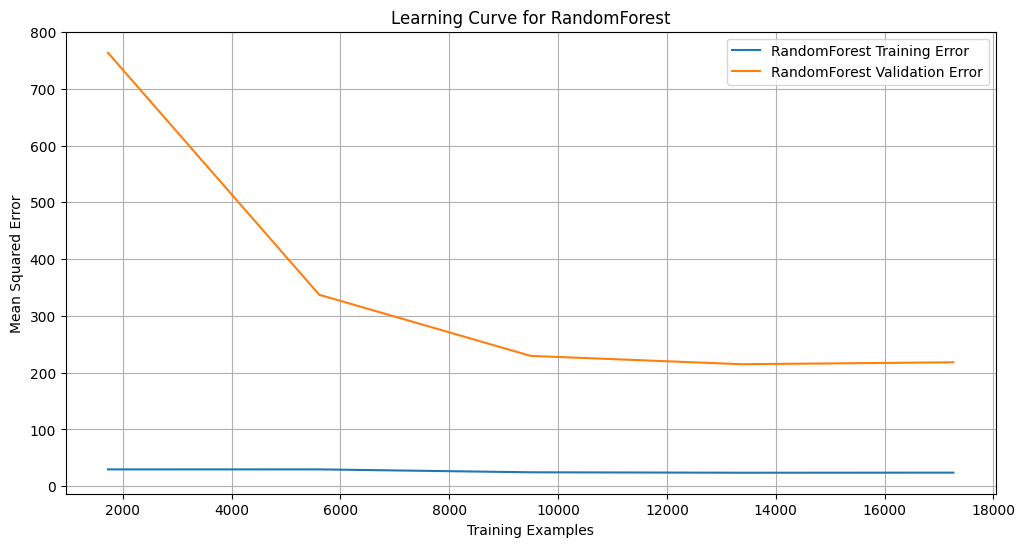

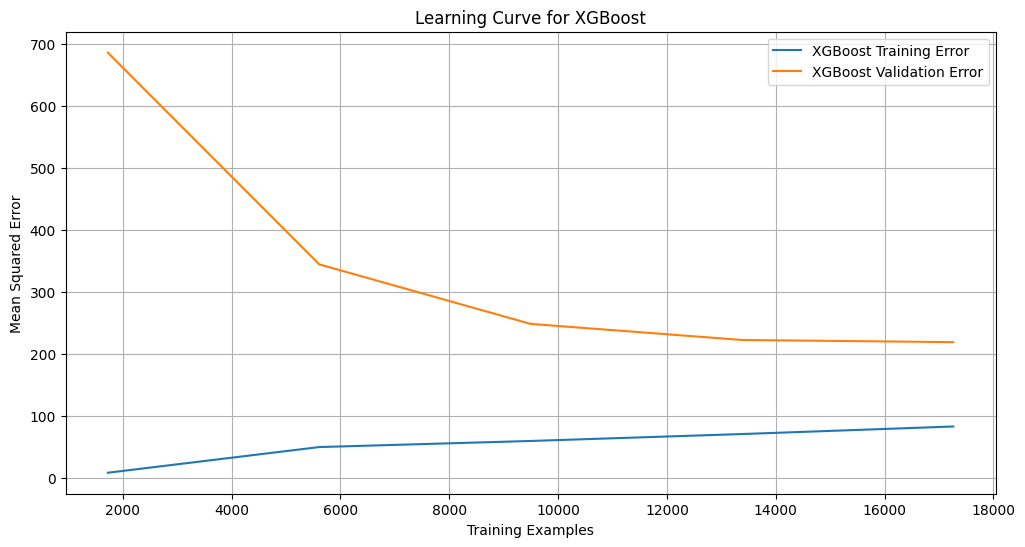

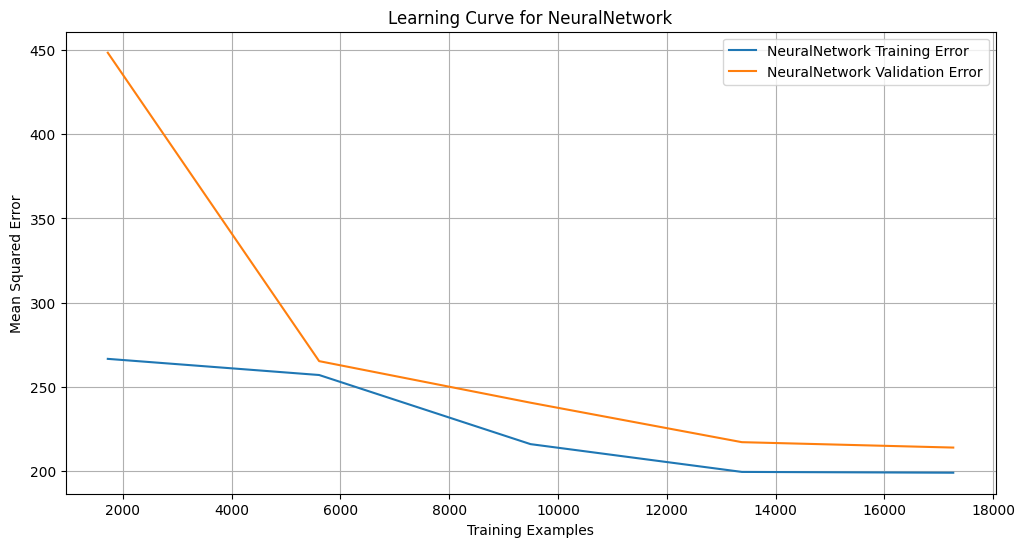

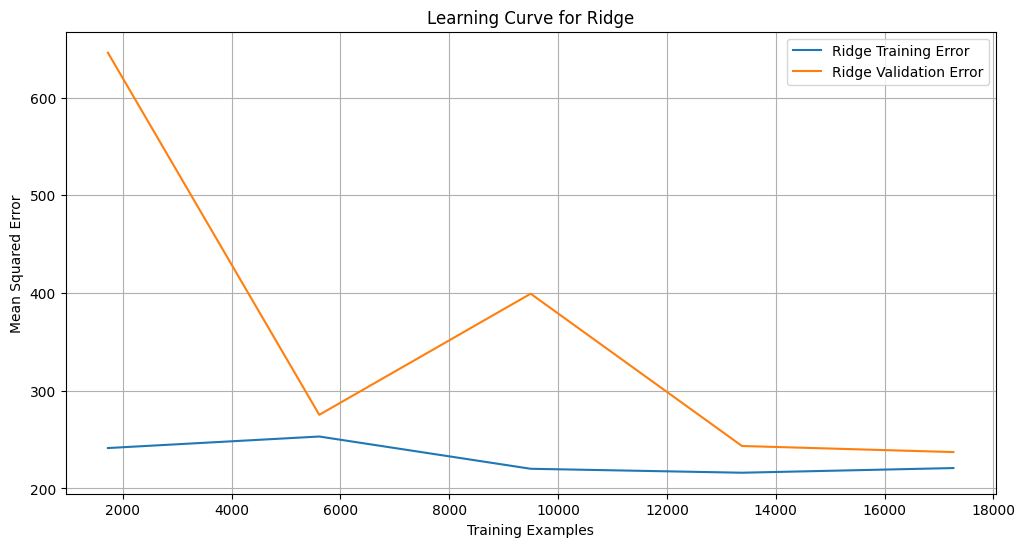

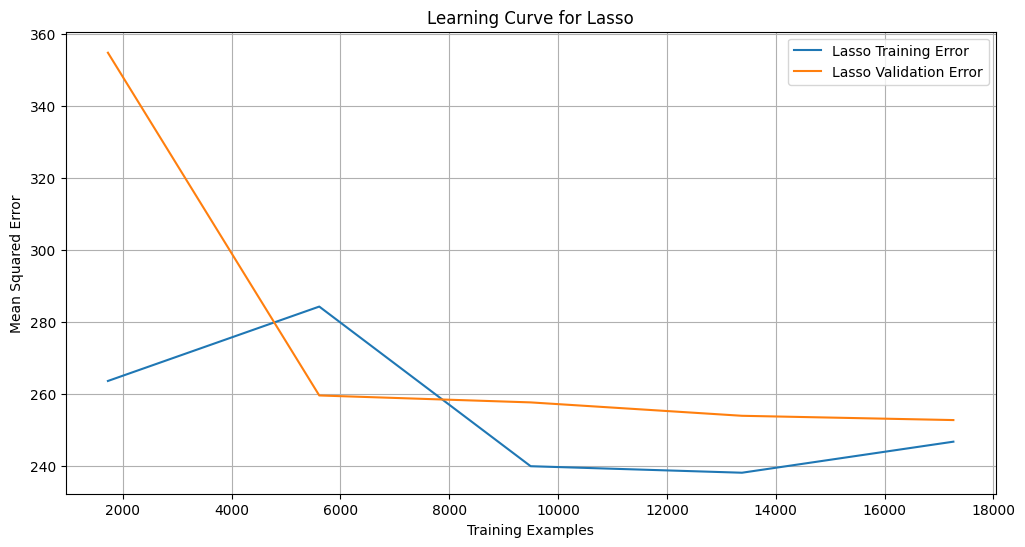

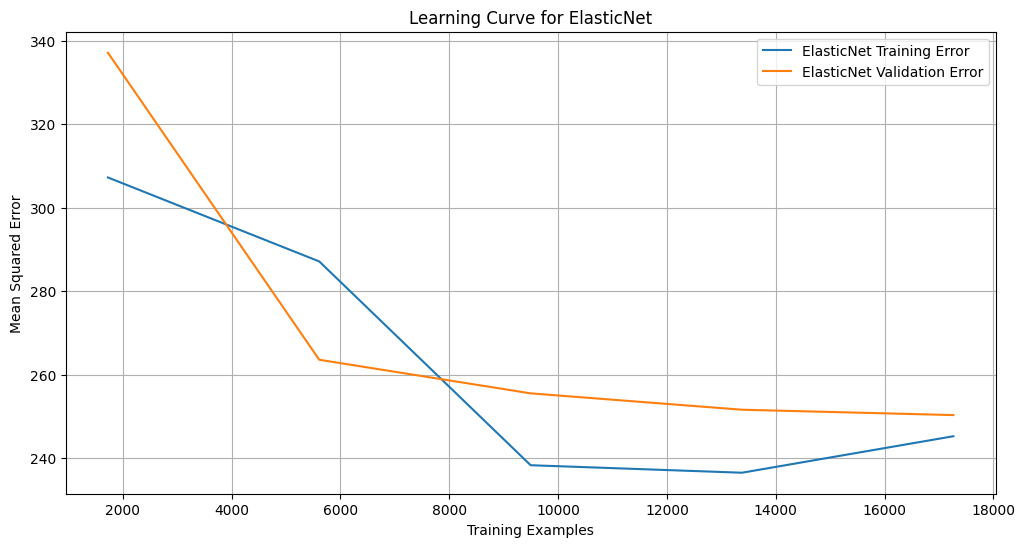

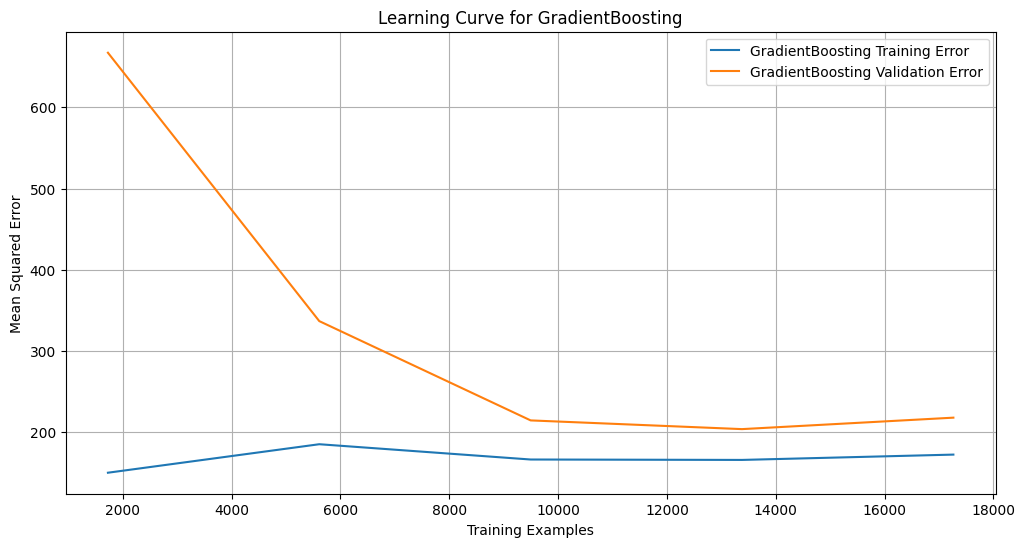

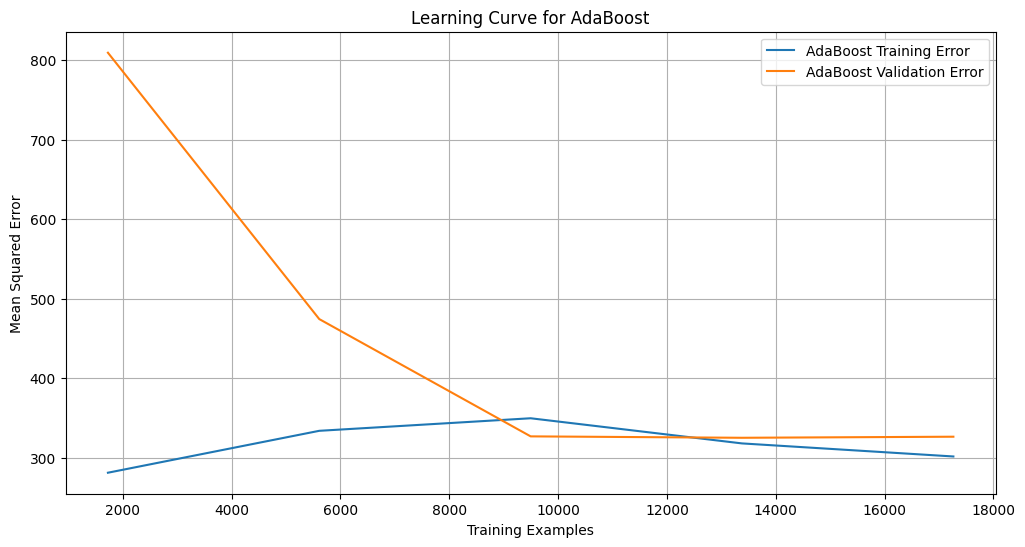

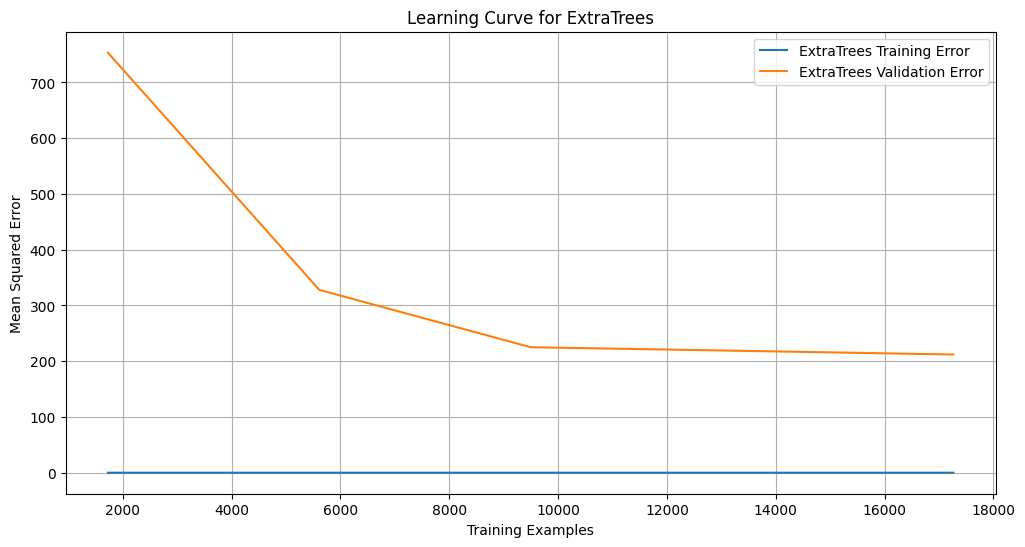

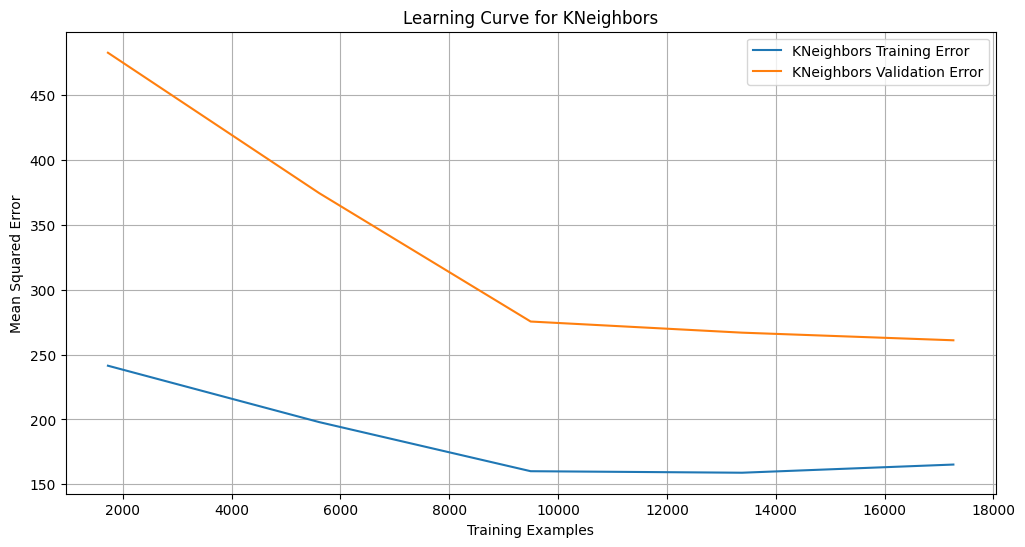

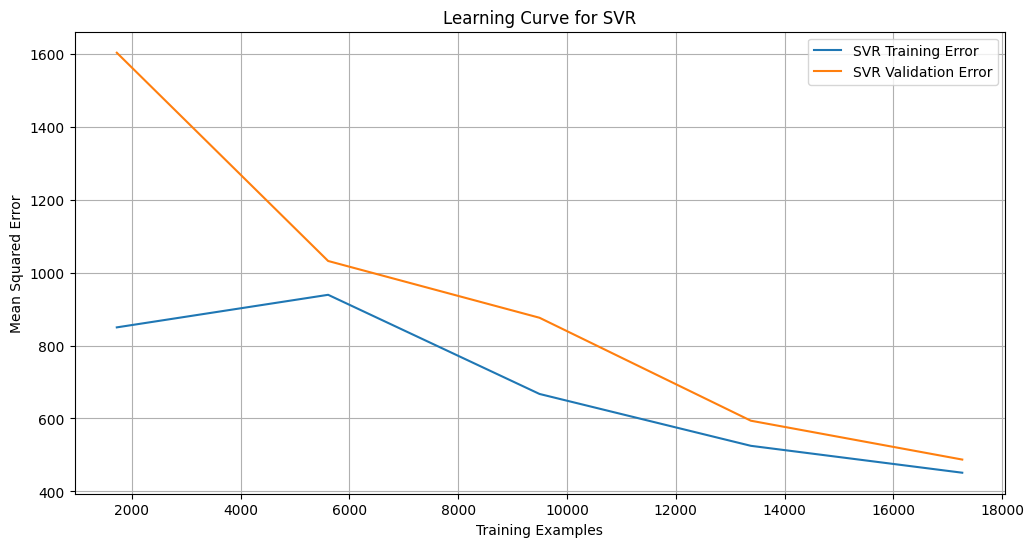

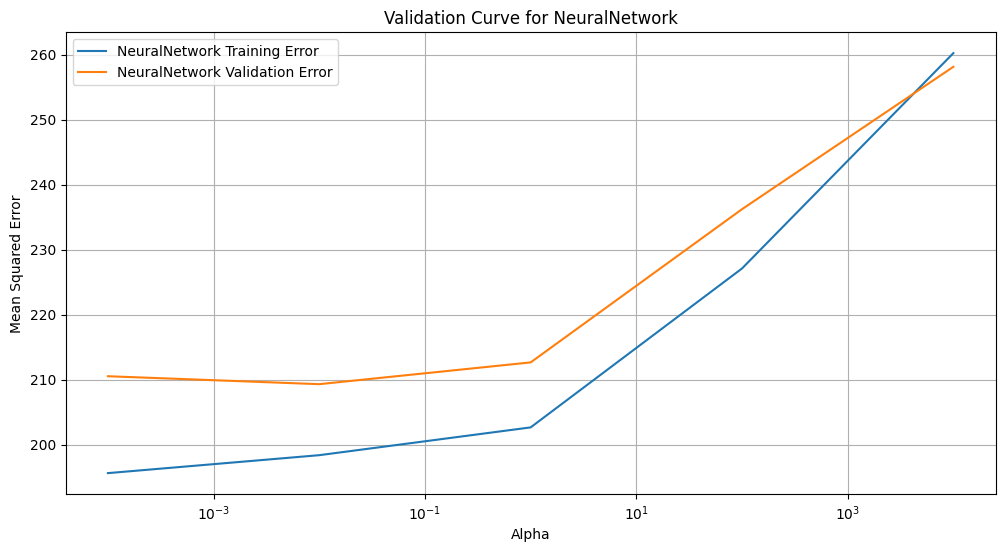

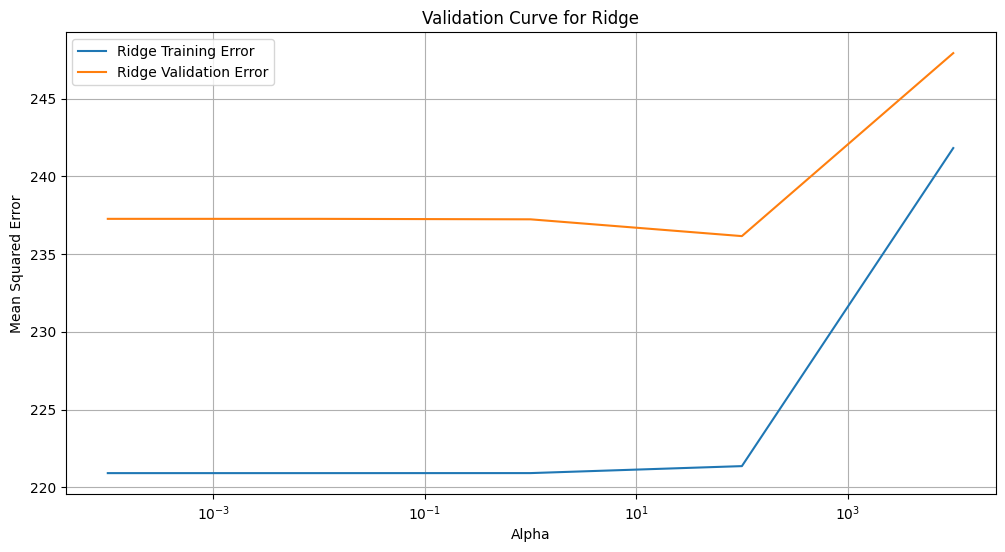

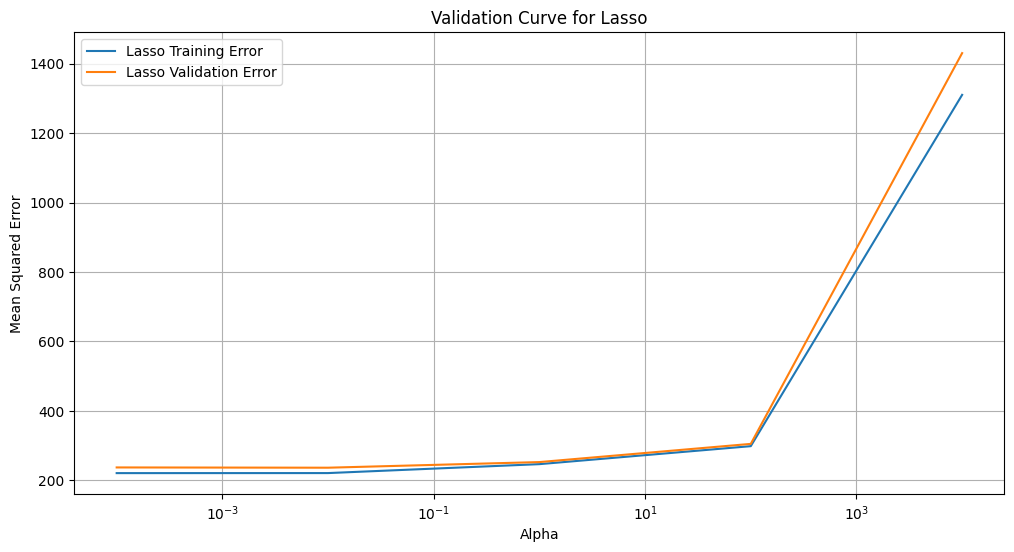

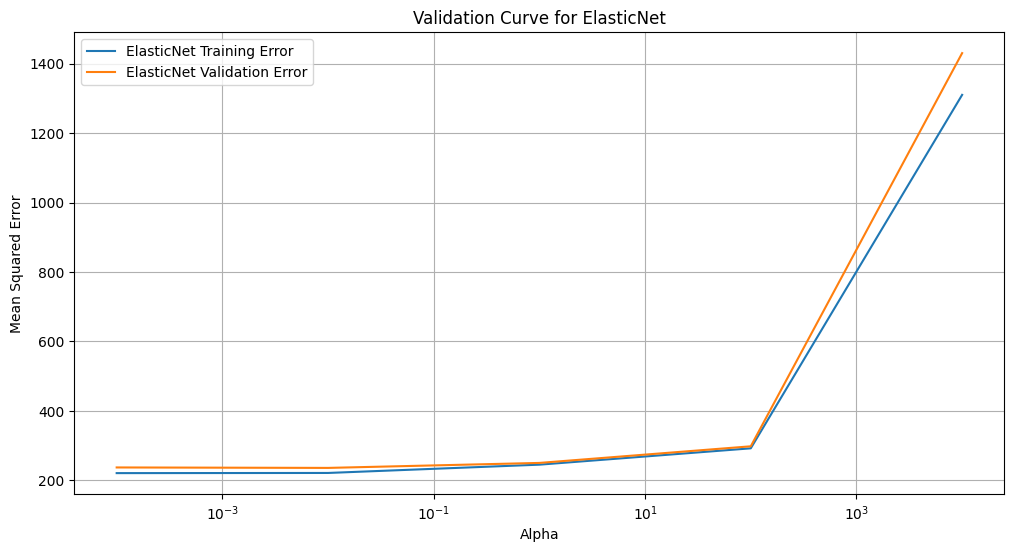

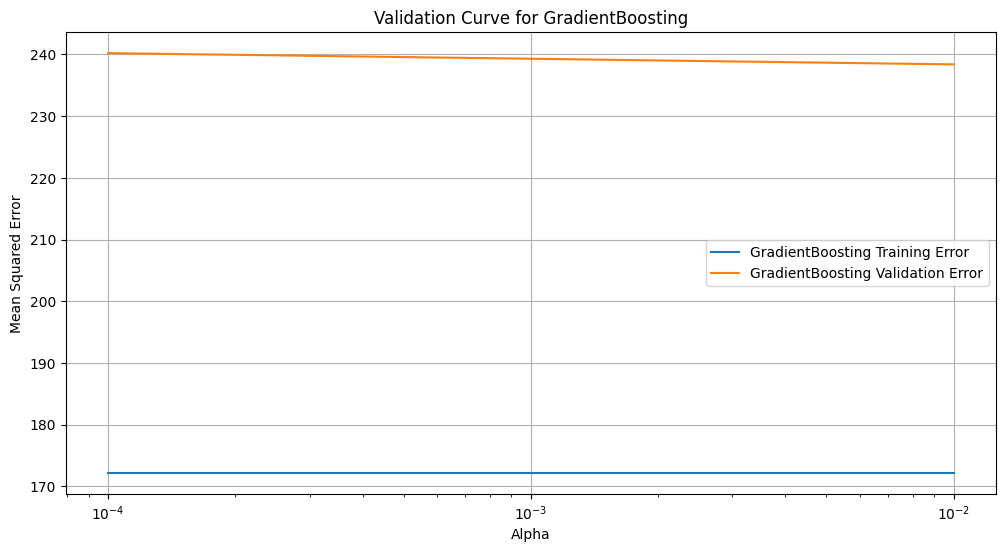

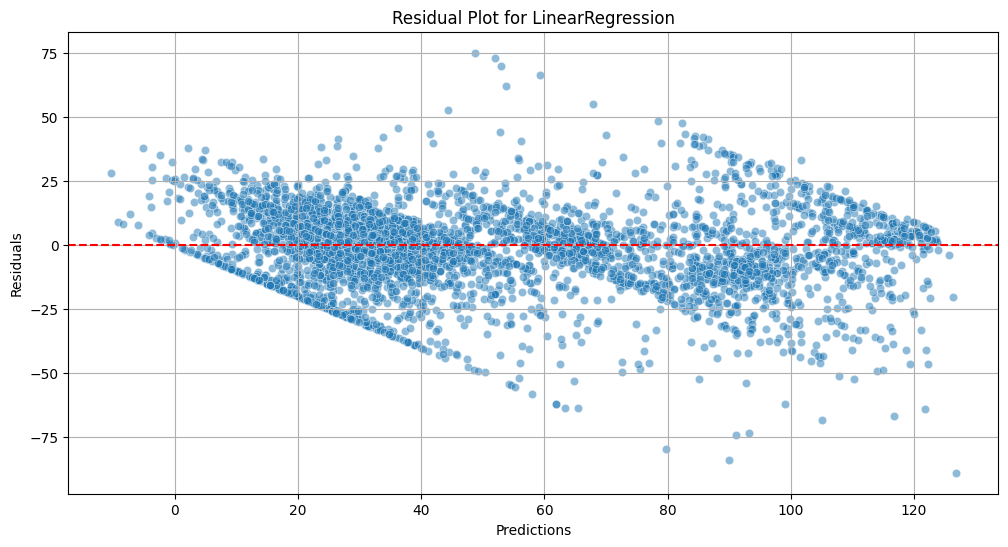

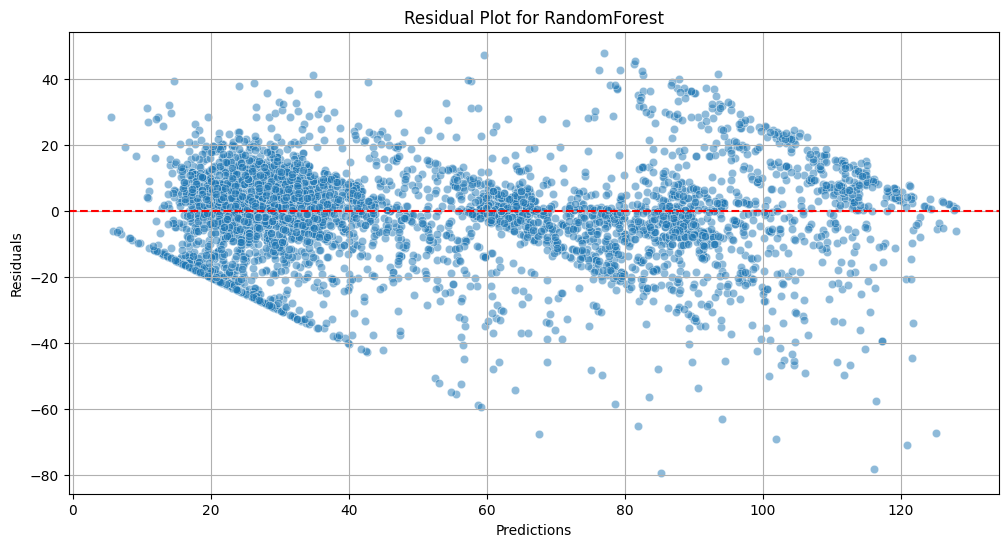

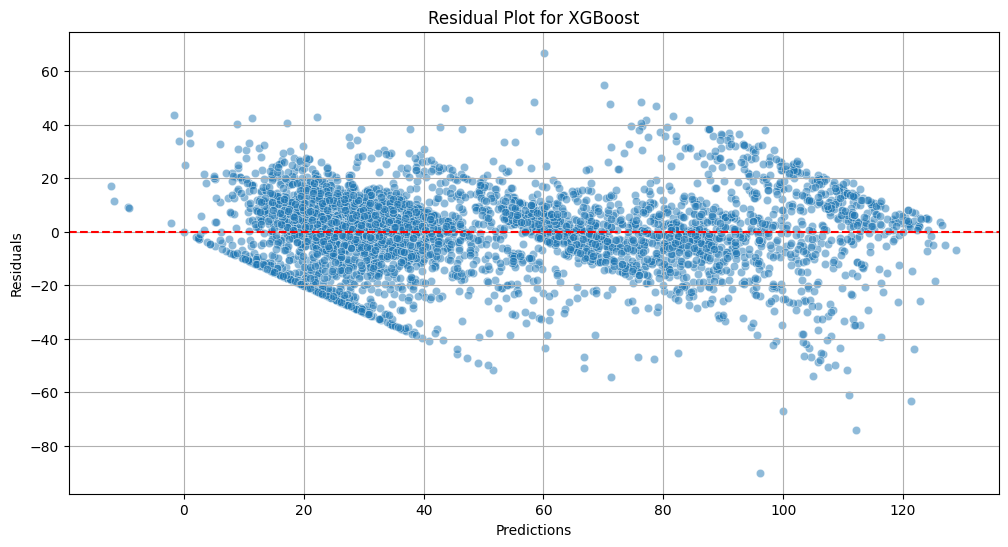

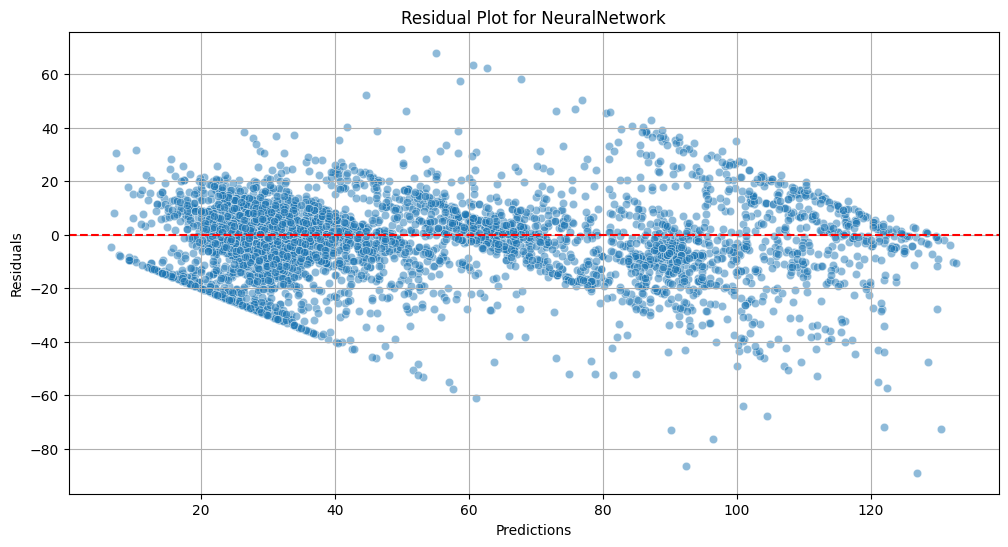

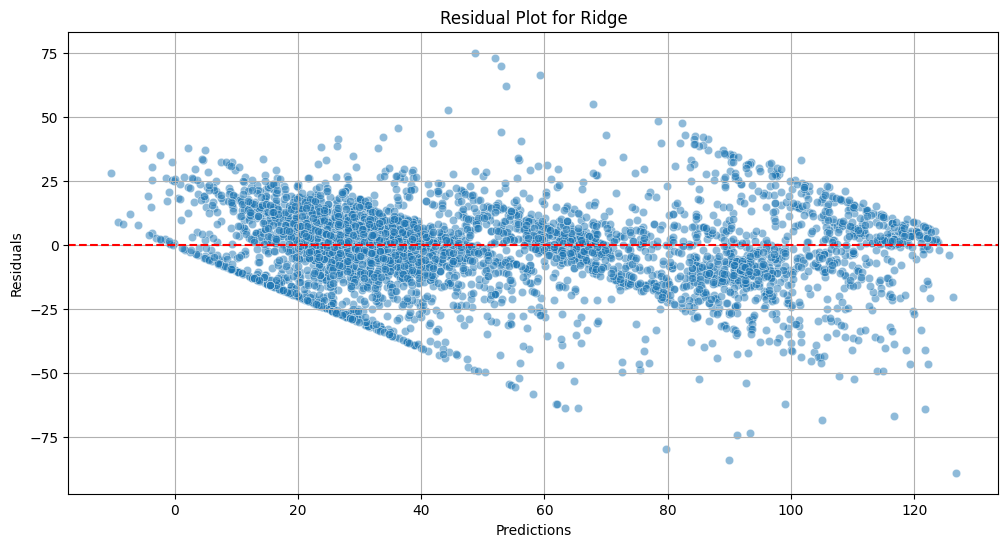

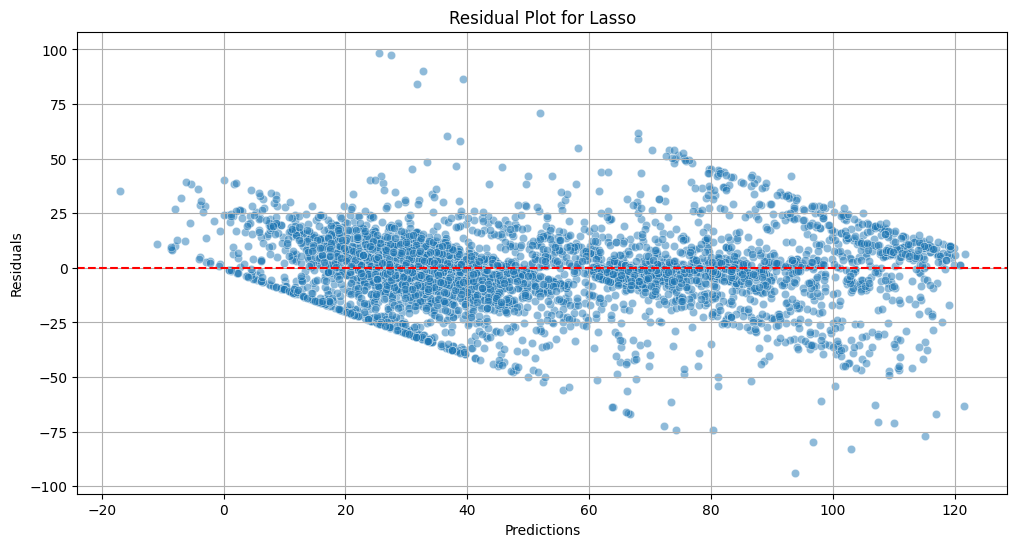

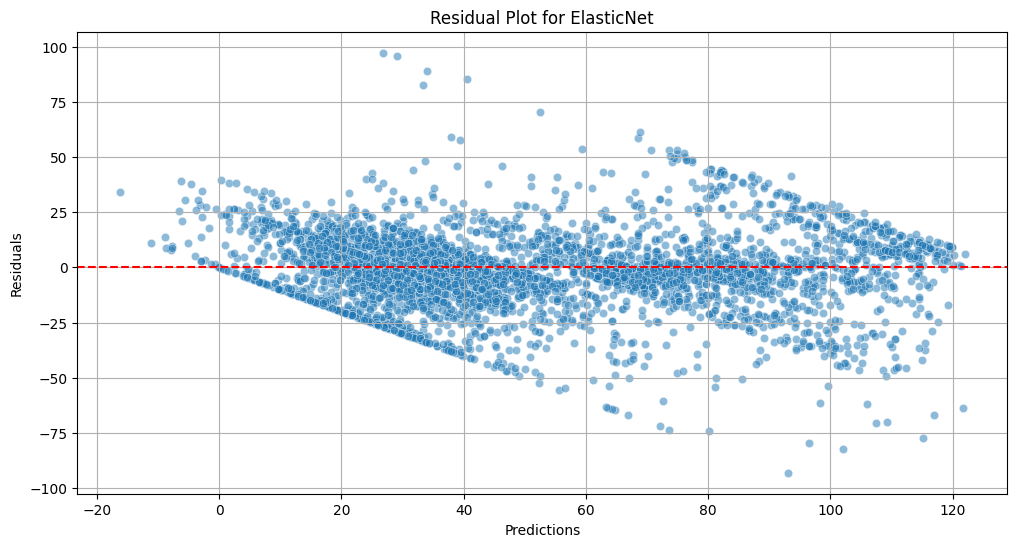

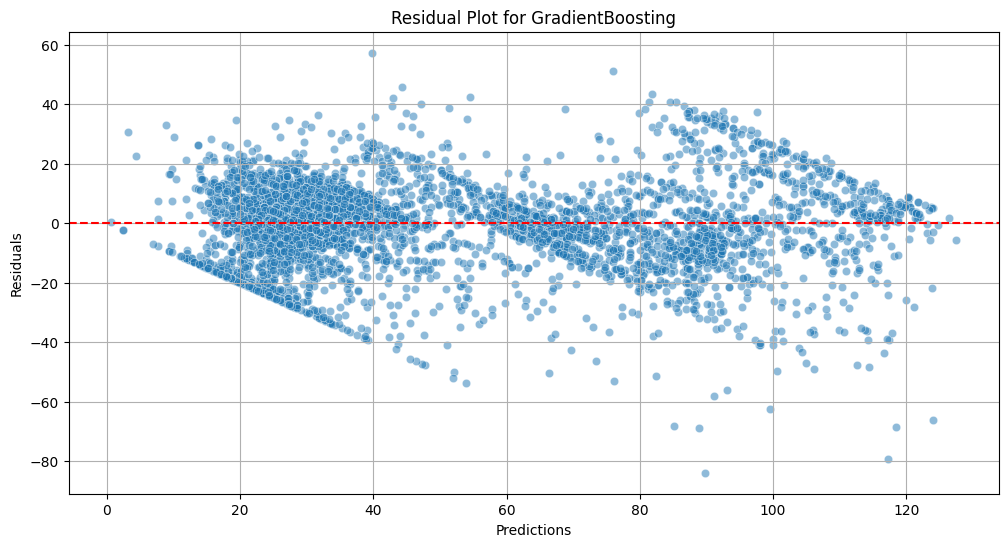

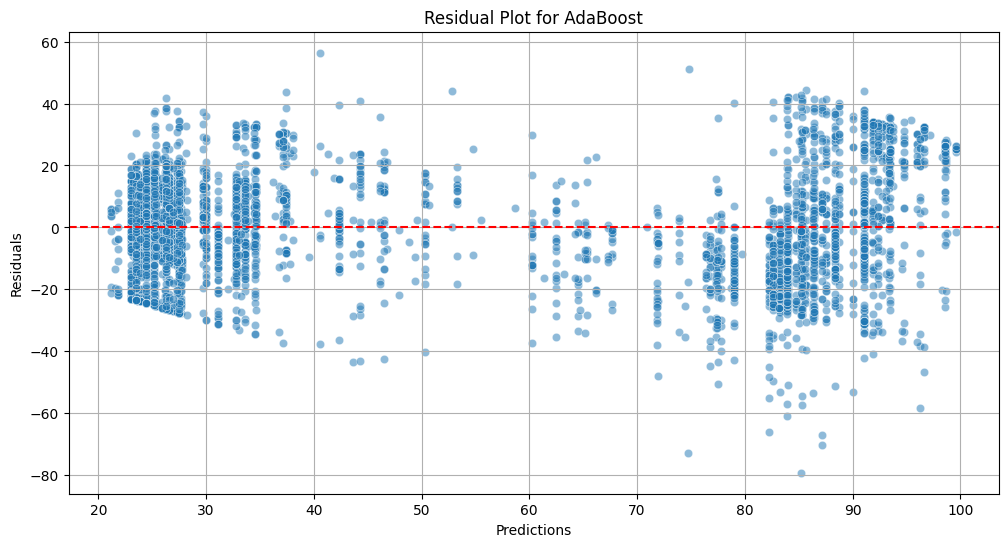

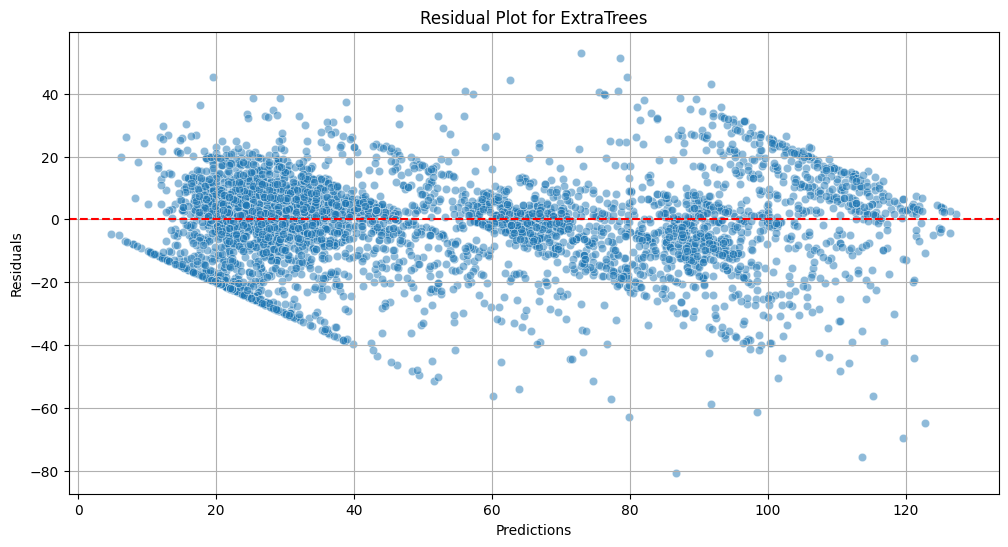

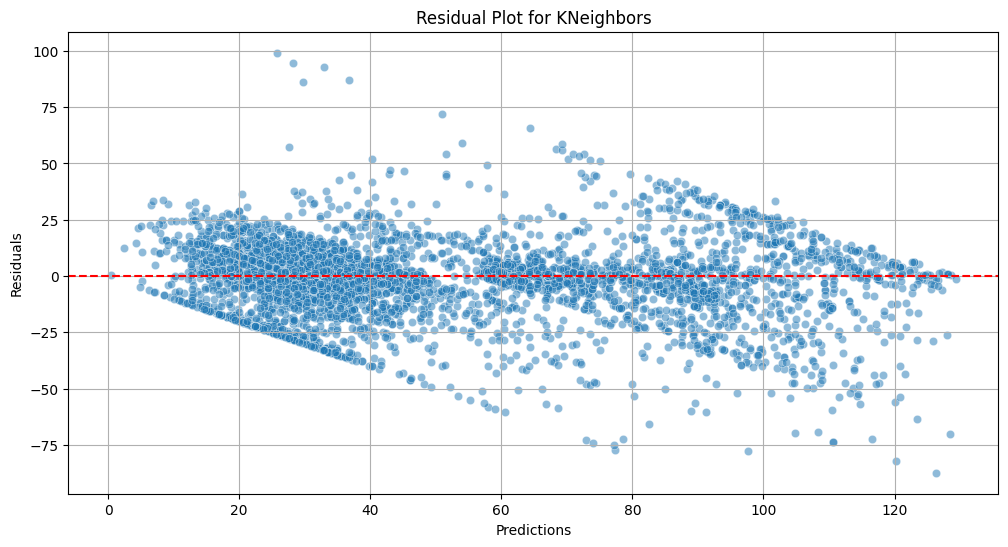

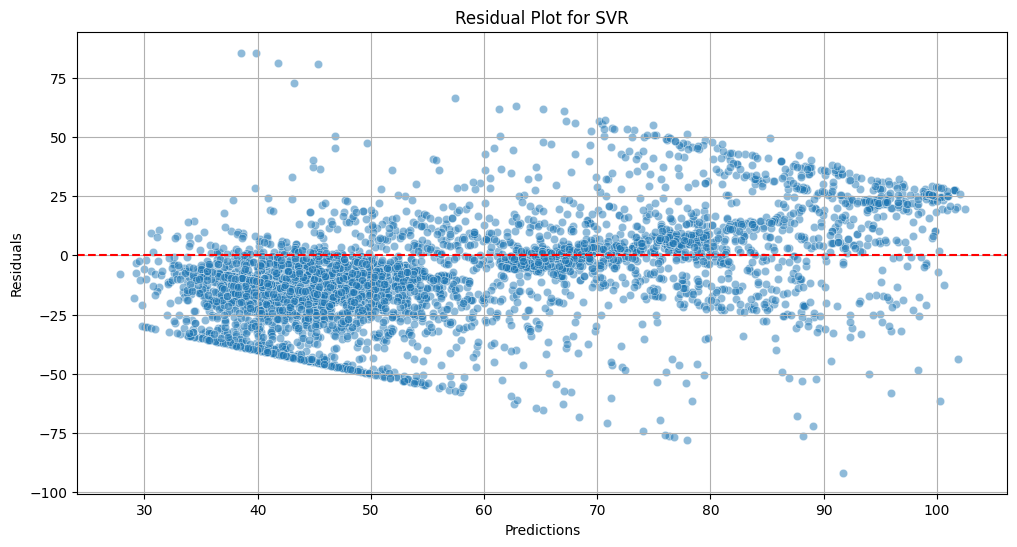

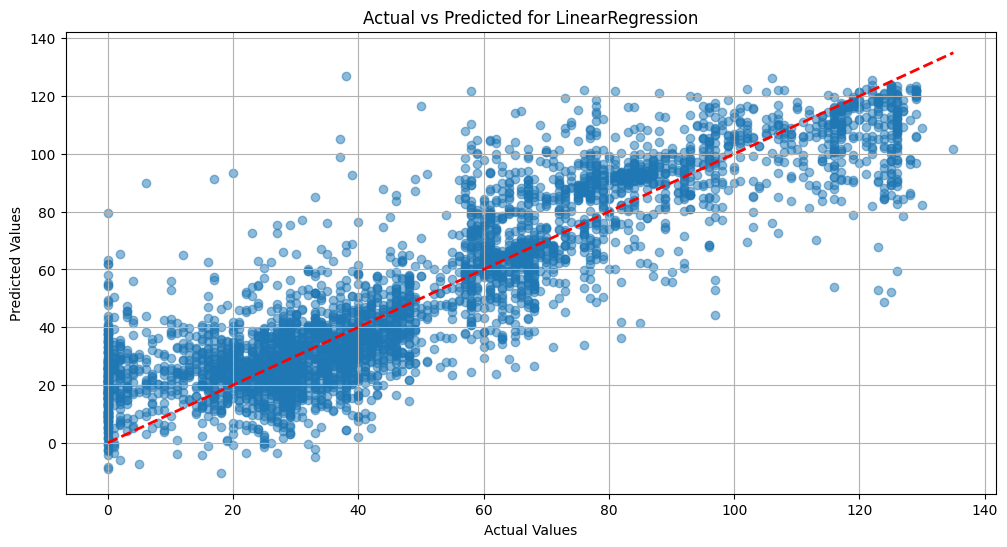

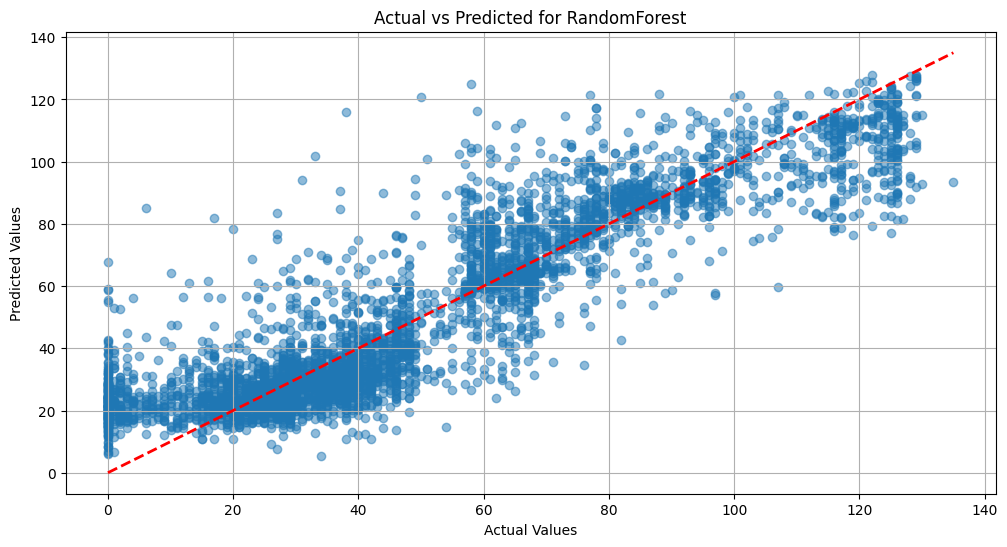

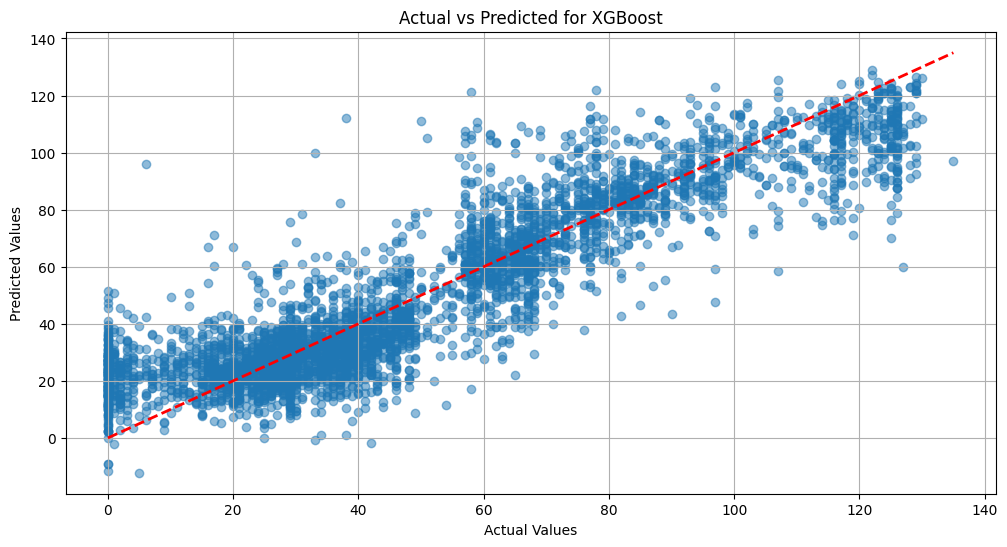

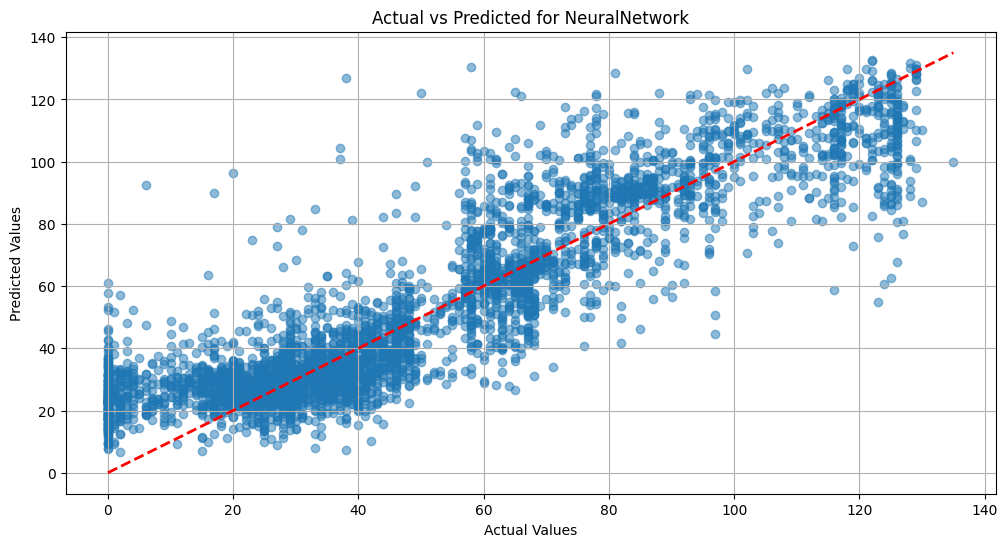

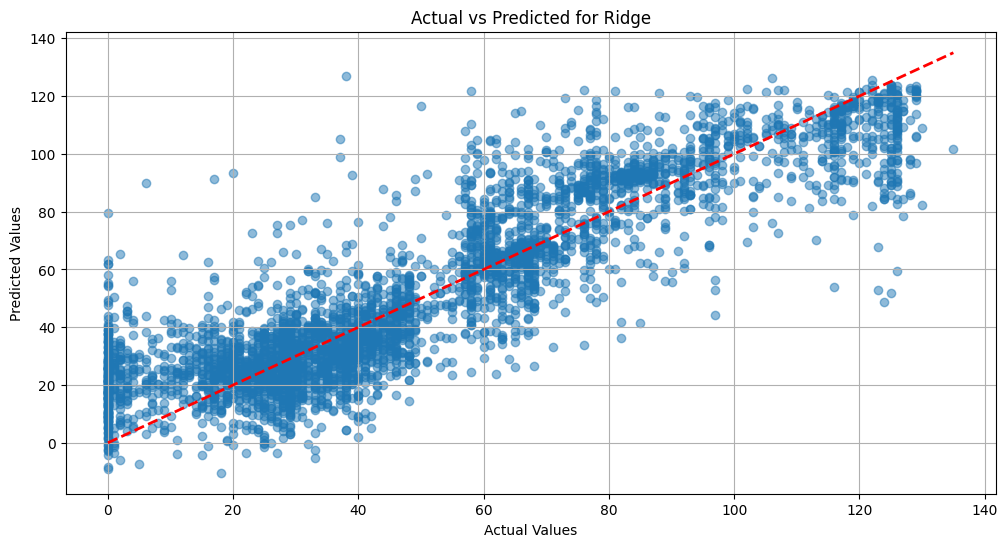

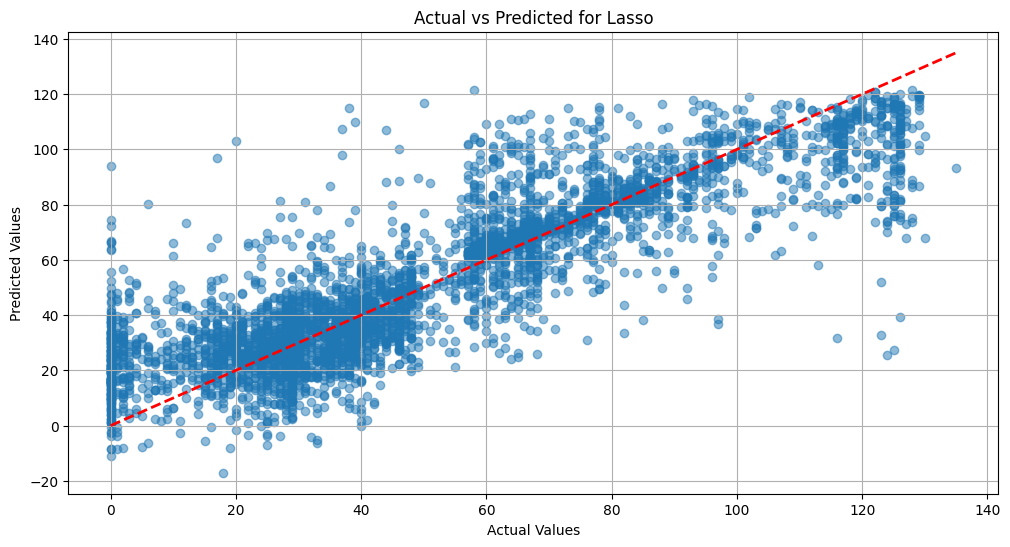

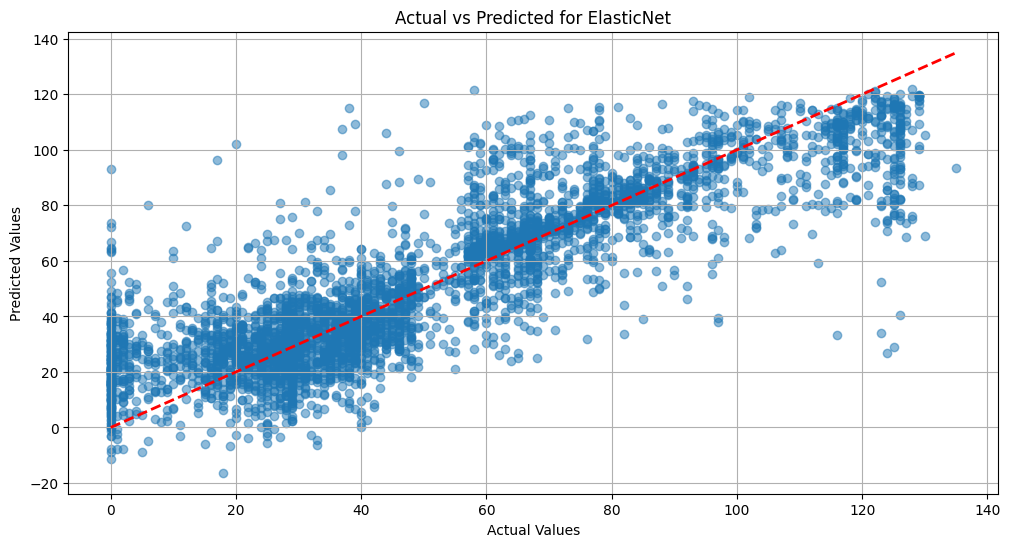

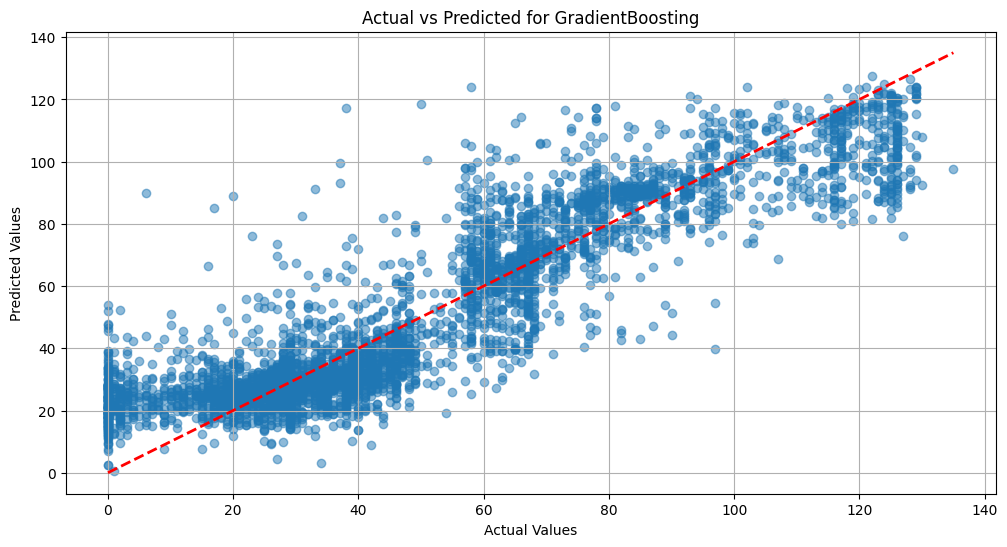

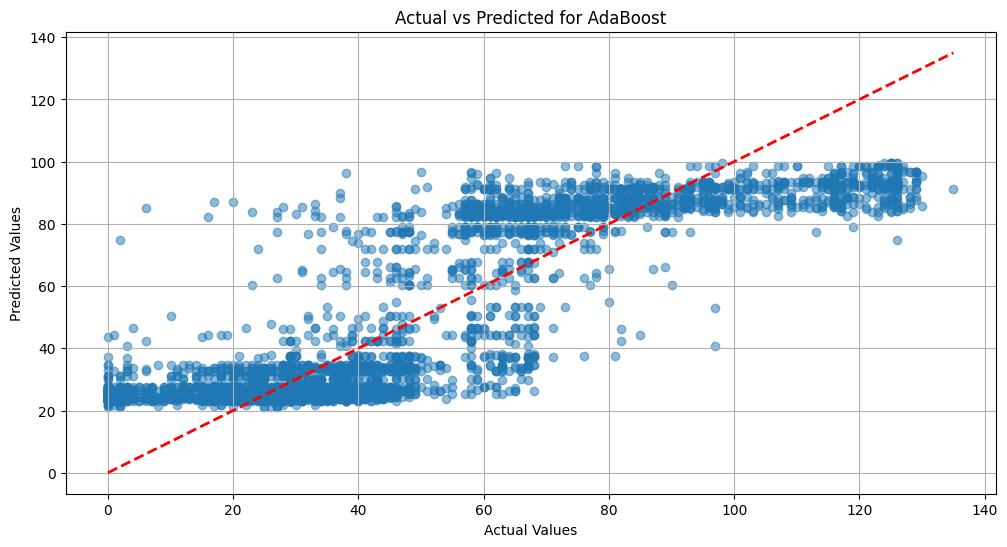

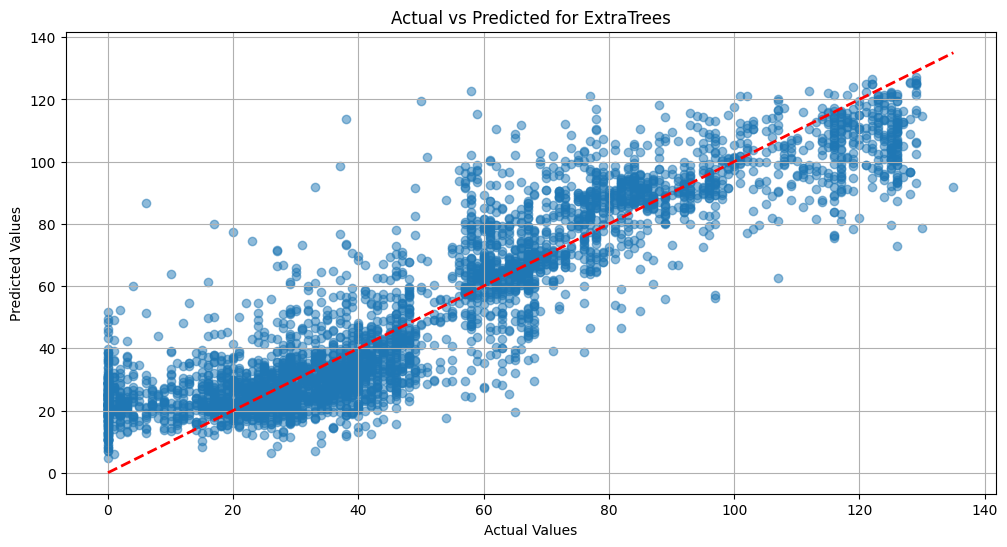

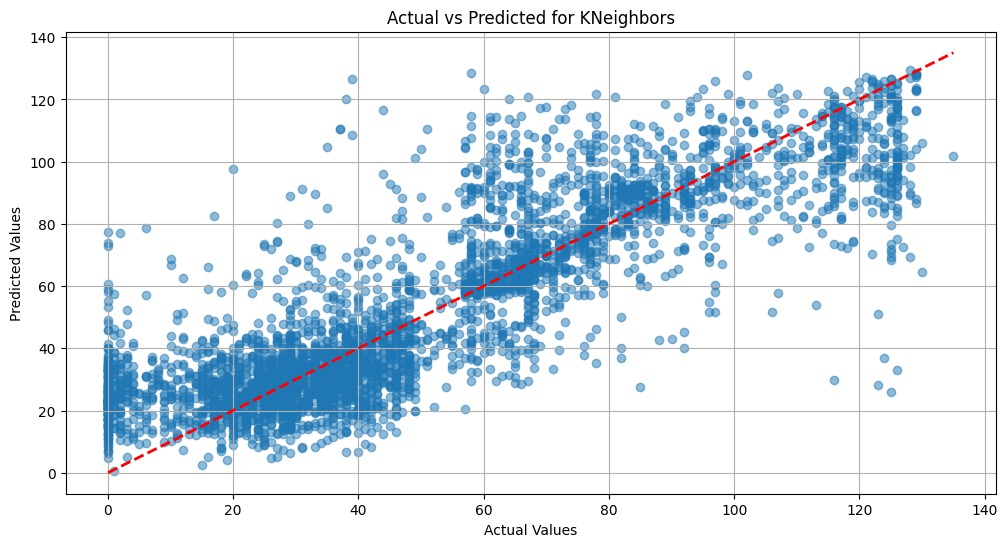

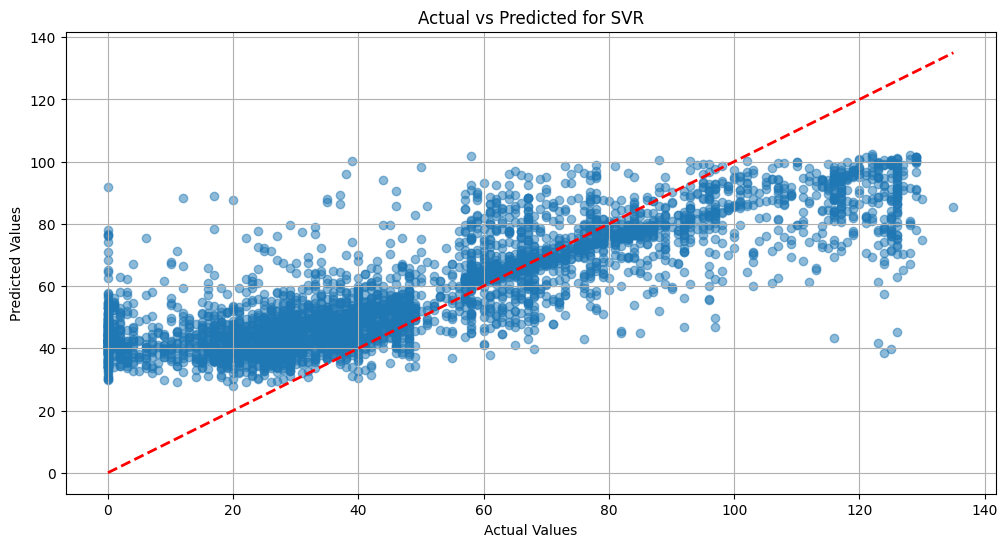

,frame_id,country_code,collection_car,time,num_vehicles_ego_lane,num_vehicles_other_lane,num_vulnerable_vehicles_ego_lane,num_vulnerable_vehicles_other_lane,num_lane_instances,num_pedestrians_ego_lane,...,weather_condition_partly-cloudy-day,weather_condition_partly-cloudy-night,weather_condition_rain,road_condition_snow,road_condition_wet,time_of_day_night,time_of_day_twilight,lag_speed_1,lag_speed_2,lag_speed_3
9150,73225.0,DE,delta,2020-02-18 08:48:00.892421+00:00,4.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,92.0,106.0,100.0
1368,73195.0,DE,delta,2020-02-18 08:48:00.892421+00:00,3.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,67.0,67.0,67.0
2298,75599.0,DE,delta,2020-02-18 08:48:00.892421+00:00,2.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,76.0,76.0,77.0
7913,80984.0,DE,delta,2020-02-18 08:48:49.892804+00:00,1.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,82.0,127.0,107.0
9151,78576.0,DE,delta,2020-02-18 08:48:49.892804+00:00,1.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,67.0,92.0,106.0
2299,70577.0,DE,delta,2020-02-18 08:48:49.892804+00:00,1.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,69.0,76.0,76.0
4672,84859.0,DE,delta,2020-02-18 08:51:25.660708+00:00,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,109.0,110.0,110.0
9152,85664.0,DE,delta,2020-02-18 08:51:25.660708+00:00,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,77.0,67.0,92.0
4673,88529.0,DE,delta,2020-02-18 08:51:25.660708+00:00,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,110.0,109.0,110.0
4822,94660.0,DE,delta,2020-02-18 08:51:25.660708+00:00,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,112.0,111.0,111.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_Dataset_DE_smogn.csv')

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# Extract temporal features from time column
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_columns = encoder.fit_transform(df[categorical_columns])

# Get the new column names
encoded_column_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoded_column_names, index=df.index)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original categorical columns
df.drop(columns=categorical_columns, inplace=True)

# Create lag features for the target variable
df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
df['lag_speed_2'] = df['average_speed_kmh'].shift(2)
df['lag_speed_3'] = df['average_speed_kmh'].shift(3)

# Create rolling average features for the target variable
#df['rolling_mean_speed_3'] = df['average_speed_kmh'].rolling(window=3, min_periods=1).mean()

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by='time')

# Drop the first few rows where lag features would be NaN (after splitting the data)
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'NeuralNetwork': MLPRegressor(max_iter=1000),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'GradientBoosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'KNeighbors': KNeighborsRegressor(),
    'SVR': SVR()
}

# Function to train and evaluate model
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)
    return mse, rmse, r2, mae, medae, predictions

# Dictionary to store results
results = {}

# Loop through models and evaluate
for model_name, model in models.items():
    mse, rmse, r2, mae, medae, predictions = train_and_evaluate_model(X_train, y_train, X_test, y_test, model)
    results[model_name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAE': mae, 'MedAE': medae, 'Predictions': predictions}

# Displaying results
for model_name, metrics in results.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}')
    print('\n')

# Plot learning curves for each model
for model_name, model in models.items():
    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    plt.figure(figsize=(12, 6))
    plt.plot(train_sizes, train_scores_mean, label=f'{model_name} Training Error')
    plt.plot(train_sizes, test_scores_mean, label=f'{model_name} Validation Error')
    plt.xlabel('Training Examples')
    plt.ylabel('Mean Squared Error')
    plt.title(f'Learning Curve for {model_name}')
    plt.legend()
    plt.grid()
    plt.show()

# Plot validation curves for each model
param_range = np.logspace(-4, 4, 5)
for model_name, model in models.items():
    if hasattr(model, 'alpha'):
        train_scores, test_scores = validation_curve(model, X, y, param_name='alpha', param_range=param_range, scoring='neg_mean_squared_error', n_jobs=-1)
        train_scores_mean = -np.mean(train_scores, axis=1)
        test_scores_mean = -np.mean(test_scores, axis=1)

        plt.figure(figsize=(12, 6))
        plt.plot(param_range, train_scores_mean, label=f'{model_name} Training Error')
        plt.plot(param_range, test_scores_mean, label=f'{model_name} Validation Error')
        plt.xscale('log')
        plt.xlabel('Alpha')
        plt.ylabel('Mean Squared Error')
        plt.title(f'Validation Curve for {model_name}')
        plt.legend()
        plt.grid()
        plt.show()

# Plot residuals for each model
for model_name, metrics in results.items():
    residuals = y_test - metrics['Predictions']
    plt.figure(figsize=(12, 6))
    sns.scatterplot(x=metrics['Predictions'], y=residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predictions')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot for {model_name}')
    plt.grid()
    plt.show()

# Plot Actual vs Predicted for each model
for model_name, metrics in results.items():
    plt.figure(figsize=(12, 6))
    plt.scatter(y_test, metrics['Predictions'], alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Actual vs Predicted for {model_name}')
    plt.grid()
    plt.show()

df.head(25)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_Dataset_DE_smogn.csv')

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# Extract temporal features from time column
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_columns = encoder.fit_transform(df[categorical_columns])

# Get the new column names
encoded_column_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoded_column_names, index=df.index)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original categorical columns
df.drop(columns=categorical_columns, inplace=True)

# Create lag features for the target variable
df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
df['lag_speed_2'] = df['average_speed_kmh'].shift(2)
df['lag_speed_3'] = df['average_speed_kmh'].shift(3)

# Create rolling average features for the target variable
#df['rolling_mean_speed_3'] = df['average_speed_kmh'].rolling(window=3, min_periods=1).mean()

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by=['collection_car', 'time'])

# Drop the first few rows where lag features would be NaN (after splitting the data)
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'NeuralNetwork': MLPRegressor(max_iter=1000),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'GradientBoosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'KNeighbors': KNeighborsRegressor(),
    'SVR': SVR()
}

# Function to train and evaluate model
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)
    return mse, rmse, r2, mae, medae, predictions

# Dictionary to store results
results = {}

# Loop through models and evaluate
for model_name, model in models.items():
    mse, rmse, r2, mae, medae, predictions = train_and_evaluate_model(X_train, y_train, X_test, y_test, model)
    results[model_name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAE': mae, 'MedAE': medae, 'Predictions': predictions}

# Displaying results
for model_name, metrics in results.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}')
    print('\n')

# # Plot learning curves for each model
# for model_name, model in models.items():
#     train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
#     train_scores_mean = -np.mean(train_scores, axis=1)
#     test_scores_mean = -np.mean(test_scores, axis=1)

#     plt.figure(figsize=(12, 6))
#     plt.plot(train_sizes, train_scores_mean, label=f'{model_name} Training Error')
#     plt.plot(train_sizes, test_scores_mean, label=f'{model_name} Validation Error')
#     plt.xlabel('Training Examples')
#     plt.ylabel('Mean Squared Error')
#     plt.title(f'Learning Curve for {model_name}')
#     plt.legend()
#     plt.grid()
#     plt.show()

# # Plot validation curves for each model
# param_range = np.logspace(-4, 4, 5)
# for model_name, model in models.items():
#     if hasattr(model, 'alpha'):
#         train_scores, test_scores = validation_curve(model, X, y, param_name='alpha', param_range=param_range, scoring='neg_mean_squared_error', n_jobs=-1)
#         train_scores_mean = -np.mean(train_scores, axis=1)
#         test_scores_mean = -np.mean(test_scores, axis=1)

#         plt.figure(figsize=(12, 6))
#         plt.plot(param_range, train_scores_mean, label=f'{model_name} Training Error')
#         plt.plot(param_range, test_scores_mean, label=f'{model_name} Validation Error')
#         plt.xscale('log')
#         plt.xlabel('Alpha')
#         plt.ylabel('Mean Squared Error')
#         plt.title(f'Validation Curve for {model_name}')
#         plt.legend()
#         plt.grid()
#         plt.show()

# # Plot residuals for each model
# for model_name, metrics in results.items():
#     residuals = y_test - metrics['Predictions']
#     plt.figure(figsize=(12, 6))
#     sns.scatterplot(x=metrics['Predictions'], y=residuals, alpha=0.5)
#     plt.axhline(y=0, color='r', linestyle='--')
#     plt.xlabel('Predictions')
#     plt.ylabel('Residuals')
#     plt.title(f'Residual Plot for {model_name}')
#     plt.grid()
#     plt.show()

# # Plot Actual vs Predicted for each model
# for model_name, metrics in results.items():
#     plt.figure(figsize=(12, 6))
#     plt.scatter(y_test, metrics['Predictions'], alpha=0.5)
#     plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
#     plt.xlabel('Actual Values')
#     plt.ylabel('Predicted Values')
#     plt.title(f'Actual vs Predicted for {model_name}')
#     plt.grid()
#     plt.show()





Model: LinearRegression, R2: 0.7583, MAE: 11.3370, RMSE: 15.1538, MedAE: 8.5379


Model: RandomForest, R2: 0.7923, MAE: 10.2925, RMSE: 14.0474, MedAE: 7.4100


Model: XGBoost, R2: 0.7967, MAE: 10.2598, RMSE: 13.8978, MedAE: 7.5311


Model: NeuralNetwork, R2: 0.7712, MAE: 11.5884, RMSE: 14.7427, MedAE: 9.7224


Model: Ridge, R2: 0.7583, MAE: 11.3360, RMSE: 15.1529, MedAE: 8.5364


Model: Lasso, R2: 0.7210, MAE: 11.7027, RMSE: 16.2796, MedAE: 8.2884


Model: ElasticNet, R2: 0.7248, MAE: 11.6478, RMSE: 16.1700, MedAE: 8.2699


Model: GradientBoosting, R2: 0.7955, MAE: 10.4941, RMSE: 13.9394, MedAE: 8.0100


Model: AdaBoost, R2: 0.7114, MAE: 13.1383, RMSE: 16.5573, MedAE: 10.9984


Model: ExtraTrees, R2: 0.8059, MAE: 10.0655, RMSE: 13.5785, MedAE: 7.4000


Model: KNeighbors, R2: 0.7035, MAE: 12.0061, RMSE: 16.7850, MedAE: 8.4000


Model: SVR, R2: 0.5125, MAE: 16.8322, RMSE: 21.5210, MedAE: 13.7505




In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Final_Dataset_FR.csv')

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# Extract temporal features from time column
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month
df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# One-hot encoding for categorical columns
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Create lag features for the target variable
df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
df['lag_speed_2'] = df['average_speed_kmh'].shift(2)

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by=['collection_car', 'time'])

# Drop the first few rows where lag features would be NaN
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Reshape data for LSTM/GRU which expect 3D input: (samples, timesteps, features)
X_train_reshaped = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_reshaped = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Function to train and evaluate deep learning model
def train_and_evaluate_dl_model(model, X_train, y_train, X_test, y_test):
    model.compile(optimizer=Adam(), loss='mse')
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)
    return mse, rmse, r2, mae, medae, predictions

# Initialize deep learning models
deep_learning_models = {
    'SimpleNN': Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1)
    ]),

    'LSTM': Sequential([
        LSTM(64, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
        Dense(32, activation='relu'),
        Dense(1)
    ]),

    'GRU': Sequential([
        GRU(64, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
        Dense(32, activation='relu'),
        Dense(1)
    ]),

    'Transformer': Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
}

# Dictionary to store results
results_dl = {}

# Train and evaluate each deep learning model
for model_name, model in deep_learning_models.items():
    if model_name in ['LSTM', 'GRU', 'CNN_LSTM']:
        mse, rmse, r2, mae, medae, predictions = train_and_evaluate_dl_model(model, X_train_reshaped, y_train, X_test_reshaped, y_test)
    else:
        mse, rmse, r2, mae, medae, predictions = train_and_evaluate_dl_model(model, X_train, y_train, X_test, y_test)

    results_dl[model_name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAE': mae, 'MedAE': medae, 'Predictions': predictions}

# Displaying results
for model_name, metrics in results_dl.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}\n')


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Model: SimpleNN, R2: 0.8706, MAE: 10.3864, RMSE: 14.7658, MedAE: 6.9049

Model: LSTM, R2: 0.8681, MAE: 10.8577, RMSE: 14.9088, MedAE: 8.3135

Model: GRU, R2: 0.8767, MAE: 10.1505, RMSE: 14.4144, MedAE: 7.3266

Model: Transformer, R2: 0.7870, MAE: 12.2609, RMSE: 18.9423, MedAE: 6.8750



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset.csv')

# Convert time to datetime format
# df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# # Extract temporal features from time column
# df['hour'] = df['time'].dt.hour
# df['day_of_week'] = df['time'].dt.dayofweek
# df['day_of_month'] = df['time'].dt.day
# df['month'] = df['time'].dt.month
# df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_columns = encoder.fit_transform(df[categorical_columns])

# Get the new column names
encoded_column_names = encoder.get_feature_names_out(categorical_columns)

# Create a DataFrame with the encoded columns
encoded_df = pd.DataFrame(encoded_columns, columns=encoded_column_names, index=df.index)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df, encoded_df], axis=1)

# Drop the original categorical columns
df.drop(columns=categorical_columns, inplace=True)

# Create lag features for the target variable
df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
df['lag_speed_2'] = df['average_speed_kmh'].shift(2)
df['lag_speed_3'] = df['average_speed_kmh'].shift(3)

# Create rolling average features for the target variable
# df['rolling_mean_speed_3'] = df['average_speed_kmh'].rolling(window=3, min_periods=1).mean()
# df['rolling_mean_speed_5'] = df['average_speed_kmh'].rolling(window=5, min_periods=1).mean()

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by=['frame_id'])

# Drop the first few rows where lag features would be NaN (after splitting the data)
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror'),
    'NeuralNetwork': MLPRegressor(max_iter=1000),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'GradientBoosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'ExtraTrees': ExtraTreesRegressor(),
    'KNeighbors': KNeighborsRegressor(),
    'SVR': SVR()
}

# Function to train and evaluate model
import time

# Function to train and evaluate model
def train_and_evaluate_model(X_train, y_train, X_test, y_test, model):
    # Record the start time for training
    train_start_time = time.time()

    # Train the model
    model.fit(X_train, y_train)

    # Record the end time for training
    train_end_time = time.time()

    # Calculate the training time
    training_time = train_end_time - train_start_time

    # Record the start time for predictions
    pred_start_time = time.time()

    # Make predictions
    predictions = model.predict(X_test)

    # Record the end time for predictions
    pred_end_time = time.time()

    # Calculate the prediction time
    prediction_time = pred_end_time - pred_start_time

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)

    # # Feature importance extraction (if applicable)
    # feature_importances = None
    # if hasattr(model, 'feature_importances_'):
    #     feature_importances = model.feature_importances_
    # elif hasattr(model, 'coef_'):
    #     feature_importances = model.coef_

    return mse, rmse, r2, mae, medae, training_time, prediction_time, predictions

# Dictionary to store results
results = {}

# Loop through models and evaluate
for model_name, model in models.items():
    mse, rmse, r2, mae, medae, training_time, prediction_time, predictions = train_and_evaluate_model(X_train, y_train, X_test, y_test, model)
    results[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae,
        'MedAE': medae,
        'TrainingTime': training_time,
        'PredictionTime': prediction_time,
        'Predictions': predictions
    }

# Displaying results
for model_name, metrics in results.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}')
    print(f'Training Time: {metrics["TrainingTime"]:.4f} seconds, Prediction Time: {metrics["PredictionTime"]:.4f} seconds')
    # if metrics['FeatureImportances'] is not None:
    #     #print("Feature Importances:")
    #     importance_df = pd.DataFrame({
    #         'Feature': X.columns,
    #         'Importance': metrics['FeatureImportances']
    #     }).sort_values(by='Importance', ascending=False)
    #     print(importance_df)
    print('\n')

#print(pd.concat([X.head(), y.head()], axis=1))


   frame_id country_code collection_car                         time  \
3         3           PL          india  2021-04-18T16:01:18.888716Z   
4         4           PL          india  2021-04-18T16:16:17.336920Z   
5         5           PL          india  2021-04-29T13:17:57.999021Z   
6         6           PL          india  2021-04-28T08:08:31.883675Z   
7         7           PL          india  2021-04-29T10:46:42.106043Z   

   num_vehicles_ego_lane  num_vehicles_other_lane  \
3                      0                        1   
4                      1                        0   
5                      0                        0   
6                      1                        0   
7                      5                        0   

   num_vulnerable_vehicles_ego_lane  num_vulnerable_vehicles_other_lane  \
3                                 3                                   3   
4                                 0                                   0   
5                      

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset.csv')

# # Convert time to datetime format
# df['time'] = pd.to_datetime(df['time'], format='ISO8601')

# # Extract temporal features from time column
# df['hour'] = df['time'].dt.hour
# df['day_of_week'] = df['time'].dt.dayofweek
# df['day_of_month'] = df['time'].dt.day
# df['month'] = df['time'].dt.month
# df['year'] = df['time'].dt.year

# List of categorical columns to encode
categorical_columns = ['road_type', 'weather_condition', 'road_condition', 'time_of_day']

# One-hot encoding for categorical columns
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Create lag features for the target variable
df['lag_speed_1'] = df['average_speed_kmh'].shift(1)
df['lag_speed_2'] = df['average_speed_kmh'].shift(2)

# Ensure proper temporal splitting by sorting data by time
df = df.sort_values(by=['collection_car', 'time'])

# Drop the first few rows where lag features would be NaN
df.dropna(inplace=True)

# Define features and target
X = df.drop(columns=['frame_id', 'country_code', 'collection_car', 'time', 'average_speed_kmh'])
y = df['average_speed_kmh']

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into train and test sets based on time (80% train, 20% test)
split_index = int(len(df) * 0.8)
X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

# Reshape data for LSTM/GRU which expect 3D input: (samples, timesteps, features)
X_train_reshaped = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_reshaped = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Function to train and evaluate deep learning model
def train_and_evaluate_dl_model(model, X_train, y_train, X_test, y_test):
    model.compile(optimizer=Adam(), loss='mse')
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    medae = median_absolute_error(y_test, predictions)
    return mse, rmse, r2, mae, medae, predictions

# Initialize deep learning models
deep_learning_models = {
    'SimpleNN': Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1)
    ]),

    'LSTM': Sequential([
        LSTM(64, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
        Dense(32, activation='relu'),
        Dense(1)
    ]),

    'GRU': Sequential([
        GRU(64, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
        Dense(32, activation='relu'),
        Dense(1)
    ]),

    'Transformer': Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
}

# Dictionary to store results
results_dl = {}

# Train and evaluate each deep learning model
for model_name, model in deep_learning_models.items():
    if model_name in ['LSTM', 'GRU', 'CNN_LSTM']:
        mse, rmse, r2, mae, medae, predictions = train_and_evaluate_dl_model(model, X_train_reshaped, y_train, X_test_reshaped, y_test)
    else:
        mse, rmse, r2, mae, medae, predictions = train_and_evaluate_dl_model(model, X_train, y_train, X_test, y_test)

    results_dl[model_name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAE': mae, 'MedAE': medae, 'Predictions': predictions}

# Displaying results
for model_name, metrics in results_dl.items():
    print(f'Model: {model_name}, R2: {metrics["R2"]:.4f}, MAE: {metrics["MAE"]:.4f}, RMSE: {metrics["RMSE"]:.4f}, MedAE: {metrics["MedAE"]:.4f}\n')


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model: SimpleNN, R2: 0.7553, MAE: 10.1105, RMSE: 14.8272, MedAE: 6.3944, Prediction Time: 2.6389 seconds

Model: LSTM, R2: 0.7547, MAE: 10.2593, RMSE: 14.8445, MedAE: 6.7262, Prediction Time: 1.9387 seconds

Model: GRU, R2: 0.7491, MAE: 10.4400, RMSE: 15.0147, MedAE: 6.9139, Prediction Time: 1.4096 seconds

Model: Transformer, R2: 0.7549, MAE: 10.1941, RMSE: 14.8396, MedAE: 6.5536, Prediction Time: 2.6744 seconds



In [ ]:
import pandas as pd

# List of CSV file paths
csv_files = [
    '/content/drive/MyDrive/Colab Notebooks/Final_Dataset_DE_smogn.csv',
    '/content/drive/MyDrive/Colab Notebooks/Final_Dataset_PL_smogn.csv',
    '/content/drive/MyDrive/Colab Notebooks/Final_Dataset_SE_smogn.csv',
    '/content/drive/MyDrive/Colab Notebooks/Final_Dataset_IT.csv',
    '/content/drive/MyDrive/Colab Notebooks/Final_Dataset_FR.csv'
]

# Load and concatenate all CSV files
dfs = [pd.read_csv(file) for file in csv_files]
merged_df = pd.concat(dfs, ignore_index=True)

# Save the merged DataFrame to a new CSV file
output_path = '/content/drive/MyDrive/Colab Notebooks/Merged_Final_Dataset.csv'
merged_df.to_csv(output_path, index=False)

print(f'Merged CSV saved to {output_path}')


Merged CSV saved to /content/drive/MyDrive/Colab Notebooks/Merged_Final_Dataset.csv
